# Siemens Advanta- Bussines Case Project 2025/2026

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import zipfile
import xml.etree.ElementTree as ET
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.express as px

from collections import Counter
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from catboost import (CatBoostRegressor,Pool,EFeaturesSelectionAlgorithm)
import shap
from support import *
from itertools import product
from prophet import Prophet


## 2. Data importation

In [2]:
SALES_PATH  = 'Case2_data_extract_share.xlsx'
MARKET_PATH = 'Case2_market_data_share.xlsx'
train_data = read_sales_sheet(SALES_PATH, 'xl/worksheets/sheet1.xml')
test_data = read_sales_sheet(SALES_PATH, 'xl/worksheets/sheet3.xml')

In [3]:
df_market = pd.read_excel(MARKET_PATH, sheet_name='Sheet1')
df_period_map = pd.read_excel(MARKET_PATH, sheet_name='Sheet2')

## 3. Data exploration and understanding

### 3.1. Changing Names and Datatypes

In [4]:
#overview the dataset
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Anon Period              4237 non-null   object
 1   TGL Biz Desc             4237 non-null   object
 2   TGL Business Unit        4237 non-null   object
 3   TGL Business Segment     4237 non-null   object
 4   TGL Business Subsegment  4237 non-null   object
 5   Orders cons. (anon)      4237 non-null   object
 6   Revenue cons. (anon)     4237 non-null   object
dtypes: object(7)
memory usage: 231.8+ KB


- At first sight, the training dataset has no missing values and have 4237 rows. 
- The datatypes, are not correct so we will have to fix them. 

In [5]:
#changing the name of the variables do it is easy to track them
train_data = train_data.rename(columns={
    'Anon Period': 'Period',
    'TGL Biz Desc': 'Biz_Desc',
    'TGL Business Unit': 'Business_Unit',
    'TGL Business Segment': 'Segment',
    'TGL Business Subsegment': 'Subsegment',
    'Orders cons. (anon)': 'Orders',
    'Revenue cons. (anon)': 'Revenue'
})

In [6]:
#changing the datatypes so it is possible to visualize the data
train_data['Period'] = train_data['Period'].round().astype('Int32')
train_data['Orders'] = train_data['Orders'].round().astype('Int32')
train_data['Revenue'] = train_data['Revenue'].round().astype('Int32')

### 3.2. Data Overview

In [7]:
#overview the dataset
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Period         4237 non-null   Int32 
 1   Biz_Desc       4237 non-null   object
 2   Business_Unit  4237 non-null   object
 3   Segment        4237 non-null   object
 4   Subsegment     4237 non-null   object
 5   Orders         4237 non-null   Int32 
 6   Revenue        4237 non-null   Int32 
dtypes: Int32(3), object(4)
memory usage: 194.6+ KB


In [8]:
df_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 78 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    180 non-null    int64  
 1   China_Core_Inflation_Rate                 178 non-null    float64
 2   China_Exports                             178 non-null    float64
 3   China_GDP                                 15 non-null     float64
 4   China_GDP_from_Construction               60 non-null     float64
 5   China_GDP_from_Manufacturing              60 non-null     float64
 6   China_Industrial_Production               176 non-null    float64
 7   China_Industrial_Production_Mom           170 non-null    float64
 8   China_Inflation_Rate                      178 non-null    float64
 9   China_Interest_Rate                       137 non-null    float64
 10  China_Steel_Production                

- Considering that the total number of rows is 180 (corresponding to the number of years), most of the columns have a considerable amount of missing values.

In [9]:
#first 20 rows
train_data.head(20)

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277
1,2,SSI,SSI027,SSI02710,SSI02710,0,334
2,3,SSI,SSI027,SSI02710,SSI02710,0,334
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468
6,7,SSI,SSI027,SSI02710,SSI02710,0,334
7,8,SSI,SSI027,SSI02710,SSI02710,0,334
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094


In [10]:
#first 20 rows
df_market.head(20)

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
0,-131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6955.00
1,-130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7264.00
2,-129,1.0,137.35,NaN,10710.5,76425.9,13.70,NaN,2.9,NaN,...,0.9,153.326,NaN,554.4,1925.9,8.5,0.2,1.1,NaN,7090.00
3,-128,1.1,145.45,NaN,NaN,NaN,13.40,NaN,3.3,NaN,...,0.9,156.763,NaN,NaN,NaN,7.7,0.4,1.2,0.25,6764.00
4,-127,1.1,139.26,NaN,NaN,NaN,13.90,NaN,3.5,NaN,...,0.9,157.769,NaN,NaN,NaN,6.9,0.4,1.1,0.25,6619.00
5,-126,1.1,144.99,NaN,18012.5,118221.6,13.30,NaN,3.6,NaN,...,0.8,158.624,NaN,549.2,1947.4,6.3,0.3,1.1,0.25,6605.00
6,-125,1.3,135.96,NaN,NaN,NaN,13.10,NaN,4.4,NaN,...,0.6,164.234,NaN,NaN,NaN,5.7,-0.3,1.2,0.25,6543.00
7,-124,1.5,153.29,NaN,NaN,NaN,13.30,NaN,5.1,NaN,...,0.8,165.621,NaN,NaN,NaN,5.4,0.1,1.1,0.25,6418.00
8,-123,1.7,154.14,6192.56,27259.3,165123.1,13.50,NaN,4.6,NaN,...,0.8,168.510,15048.97,545.1,1957.6,6.1,1.0,1.5,0.25,6648.00
9,-122,2.3,150.70,NaN,NaN,NaN,13.41,NaN,4.9,NaN,...,1.0,169.897,NaN,NaN,NaN,4.7,-0.2,1.6,0.25,7191.38


In [11]:
#descriptive statistics for numerical data
train_data.describe()

,Period,Orders,Revenue
count,4237.0,4237.0,4237.0
mean,22.510031,40076623.578475,35976412.567855
std,12.238664,70414862.658063,63786043.938389
min,1.0,-56101878.0,-12010755.0
25%,12.0,871389.0,1020192.0
50%,23.0,9281978.0,8850535.0
75%,33.0,43312847.0,36460128.0
max,42.0,595094385.0,420036087.0


- The dataset has 42 months.
- There are rows in *Orders* and *Revenue* that are negative- Is it possible?

In [12]:
#descriptive statistics for numerical data
df_market.describe().round(2)

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
count,180.00,178.00,178.00,15.00,60.00,60.00,176.00,170.00,178.00,137.00,...,178.00,178.00,15.00,60.00,60.00,178.00,178.00,178.00,175.00,180.00
mean,-41.50,1.37,215.89,13031.13,33122.37,173068.40,7.42,0.65,2.08,4.21,...,2.59,209.07,20549.85,719.75,2129.46,1.03,0.07,2.60,1.43,6908.79
std,52.11,0.60,56.05,4130.32,22602.81,96035.07,5.04,3.29,1.49,0.69,...,1.40,31.90,4404.15,143.70,148.43,3.86,1.33,1.98,1.75,529.05
min,-131.00,-0.30,80.38,6192.56,4749.00,42670.30,-13.50,-22.10,-0.80,3.10,...,0.60,147.14,15048.97,533.20,1906.30,-17.20,-13.20,-0.20,0.25,4746.00
25%,-86.25,0.90,177.79,10208.83,13793.25,93960.05,5.40,0.44,1.30,3.70,...,1.70,188.11,17244.41,572.33,2000.15,-0.98,-0.28,1.42,0.25,6648.25
50%,-41.50,1.50,204.65,12537.56,28693.25,163199.35,6.30,0.55,2.00,4.30,...,2.10,198.92,19612.10,654.10,2104.35,1.60,0.10,2.10,0.25,6955.50
75%,3.25,1.80,263.34,16599.06,47756.28,227774.98,9.05,0.76,2.70,4.31,...,3.18,215.55,22610.57,867.68,2251.68,3.18,0.50,3.08,2.00,7270.16
max,48.00,2.50,339.66,18743.80,88862.80,404518.50,35.10,36.56,6.50,5.77,...,6.60,283.27,29184.89,904.40,2389.00,16.10,6.60,9.10,5.50,7960.90


- Unlike *train_data*, the period goes form -131 to 48. 

In [13]:
train_data.nunique()

Period             42
Biz_Desc            1
Business_Unit       4
Segment            24
Subsegment        134
Orders           3943
Revenue          3958
dtype: int64

In [14]:
df_market.nunique()

Period                                     180
China_Core_Inflation_Rate                   28
China_Exports                              176
China_GDP                                   15
China_GDP_from_Construction                 60
                                          ... 
United_States_Industrial_Production         88
United_States_Industrial_Production_Mom     34
United_States_Inflation_Rate                62
United_States_Interest_Rate                 17
United_States_Steel_Production             142
Length: 78, dtype: int64

### 3.3. Checking Duplicates

In [15]:
#checking number of duplicates
train_data.duplicated().sum()

np.int64(0)

In [16]:
#checking number of duplicates
df_market.duplicated().sum()

np.int64(0)

- None of the datasets present duplicates.

### 3.4. Checking Missing Values

In [17]:
#checking number of missing values
train_data.isna().sum()

Period           0
Biz_Desc         0
Business_Unit    0
Segment          0
Subsegment       0
Orders           0
Revenue          0
dtype: int64

- The train dataset does not present any missing values which is a good sign.

In [18]:
#checking number of missing values
df_market.isna().sum()

Period                                       0
China_Core_Inflation_Rate                    2
China_Exports                                2
China_GDP                                  165
China_GDP_from_Construction                120
                                          ... 
United_States_Industrial_Production          2
United_States_Industrial_Production_Mom      2
United_States_Inflation_Rate                 2
United_States_Interest_Rate                  5
United_States_Steel_Production               0
Length: 78, dtype: int64

In [19]:
pd.set_option('display.max_rows', None)
df_market.isna().sum()/len(df_market) * 100

Period                                       0.000000
China_Core_Inflation_Rate                    1.111111
China_Exports                                1.111111
China_GDP                                   91.666667
China_GDP_from_Construction                 66.666667
China_GDP_from_Manufacturing                66.666667
China_Industrial_Production                  2.222222
China_Industrial_Production_Mom              5.555556
China_Inflation_Rate                         1.111111
China_Interest_Rate                         23.888889
China_Steel_Production                       0.000000
France_Core_Inflation_Rate                   1.111111
France_Exports                               1.111111
France_GDP                                  91.666667
France_GDP_from_Construction                66.666667
France_GDP_from_Manufacturing               66.666667
France_Industrial_Production                 1.111111
France_Industrial_Production_Mom             1.111111
France_Inflation_Rate       

- The variables whose missing values represent more than 50% of the data correspond to columns that have informatio about the GDP
Some columns present a high amount of missing values- almost 92% of the total data. In those cases, the information given is not sufficiently significant to consider these variables.
- 

- Data that have more than 50% of missing observations correspond to the GDP columns of each country (for example, China_GDP, China_GDP_from_Construction, China_GDP_from_Manufacturing, etc). In these cases, it is normal for the GDP to have a high quantity of missing values considering that the GDP of each country can only be calculated at the end of each year and since we have our data per month, this is the usual behavior. 
- The rest of the columns have less than 50% of missing values (usually the values do not exceed 5%, except for steel production).For the columns corresponding to steel production, there are some countries that for the possitive months (the ones we are going to consider later on merge) have 100% of missing values. 

In [20]:
#creating a variable that has df_market data from the 1 to 42 months 
df_market_months = df_market[df_market['Period'].between(1, 42)]

In [21]:
pd.set_option('display.max_rows', None)
df_market_months.isna().sum()/len(df_market_months) * 100

Period                                        0.000000
China_Core_Inflation_Rate                     0.000000
China_Exports                                 0.000000
China_GDP                                    92.857143
China_GDP_from_Construction                  66.666667
China_GDP_from_Manufacturing                 66.666667
China_Industrial_Production                   2.380952
China_Industrial_Production_Mom               0.000000
China_Inflation_Rate                          0.000000
China_Interest_Rate                           0.000000
China_Steel_Production                        0.000000
France_Core_Inflation_Rate                    0.000000
France_Exports                                0.000000
France_GDP                                   92.857143
France_GDP_from_Construction                 66.666667
France_GDP_from_Manufacturing                66.666667
France_Industrial_Production                  0.000000
France_Industrial_Production_Mom              0.000000
France_Inf

- If we consider only the observations whose period we are going to consider when merging with *train_data*, some of these observations have 100% missing values. In those cases, it is useless to consider them. 
- All variables that have missing values, also have a high percentage (>60%), except for *United_States_Interest_Rate* that has only 2.3% and *China_Industrial_Production* that has 2.3%. Therefore, these are the only variables worth of handling missing values.

### 3.5. Checking Outliers

In [22]:
#setting metric fearures for train_data
metric_features_train= ['Revenue', 'Orders']

In [23]:
#setting metric fearures for df_market
metric_features_market= ['China_Core_Inflation_Rate', 'China_Exports', 'China_GDP', 
                         'China_Industrial_Production', 'China_Industrial_Production_Mom', 
                         'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production', 
                         'France_Core_Inflation_Rate', 'France_Exports', 'France_Industrial_Production',
                         'France_Industrial_Production_Mom', 'France_Inflation_Rate', 'France_Interest_Rate', 
                         'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_Industrial_Production', 
                         'Germany_Industrial_Production_Mom', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 
                         'Germany_Steel_Production', 'Italy_Core_Inflation_Rate', 'Italy_Exports', 'Italy_Industrial_Production',
                         'Italy_Industrial_Production_Mom', 'Italy_Inflation_Rate', 'Italy_Interest_Rate', 'Japan_Core_Inflation_Rate',
                         'Japan_Exports', 'Japan_Industrial_Production', 'Japan_Industrial_Production_Mom', 'Japan_Inflation_Rate', 
                         'Japan_Interest_Rate', 'Japan_Steel_Production', 'Switzerland_Core_Inflation_Rate', 'Switzerland_Exports', 
                         'Switzerland_Inflation_Rate', 'Switzerland_Interest_Rate', 'United_Kingdom_Core_Inflation_Rate', 'United_Kingdom_Exports', 
                         'United_Kingdom_Industrial_Production', 'United_Kingdom_Industrial_Production_Mom', 'United_Kingdom_Inflation_Rate', 
                         'United_Kingdom_Interest_Rate', 'United_States_Core_Inflation_Rate', 'United_States_Exports', 
                         'United_States_Industrial_Production', 'United_States_Industrial_Production_Mom', 'United_States_Inflation_Rate', 
                         'United_States_Steel_Production'
]

In [24]:
def plot_multiple_boxplots(data, feats, n_cols=2, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

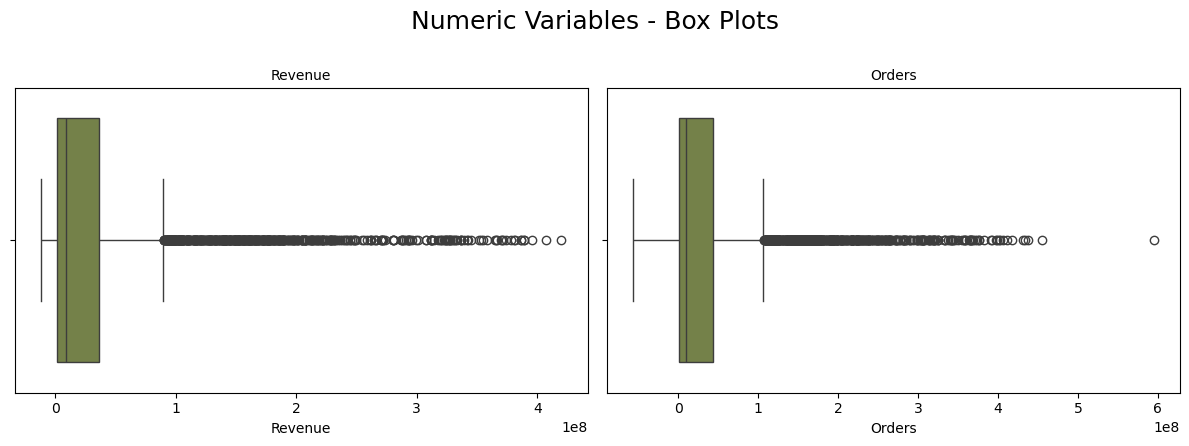

In [25]:
#applying the function to our numerical features
plot_multiple_boxplots(train_data, metric_features_train)

In [26]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

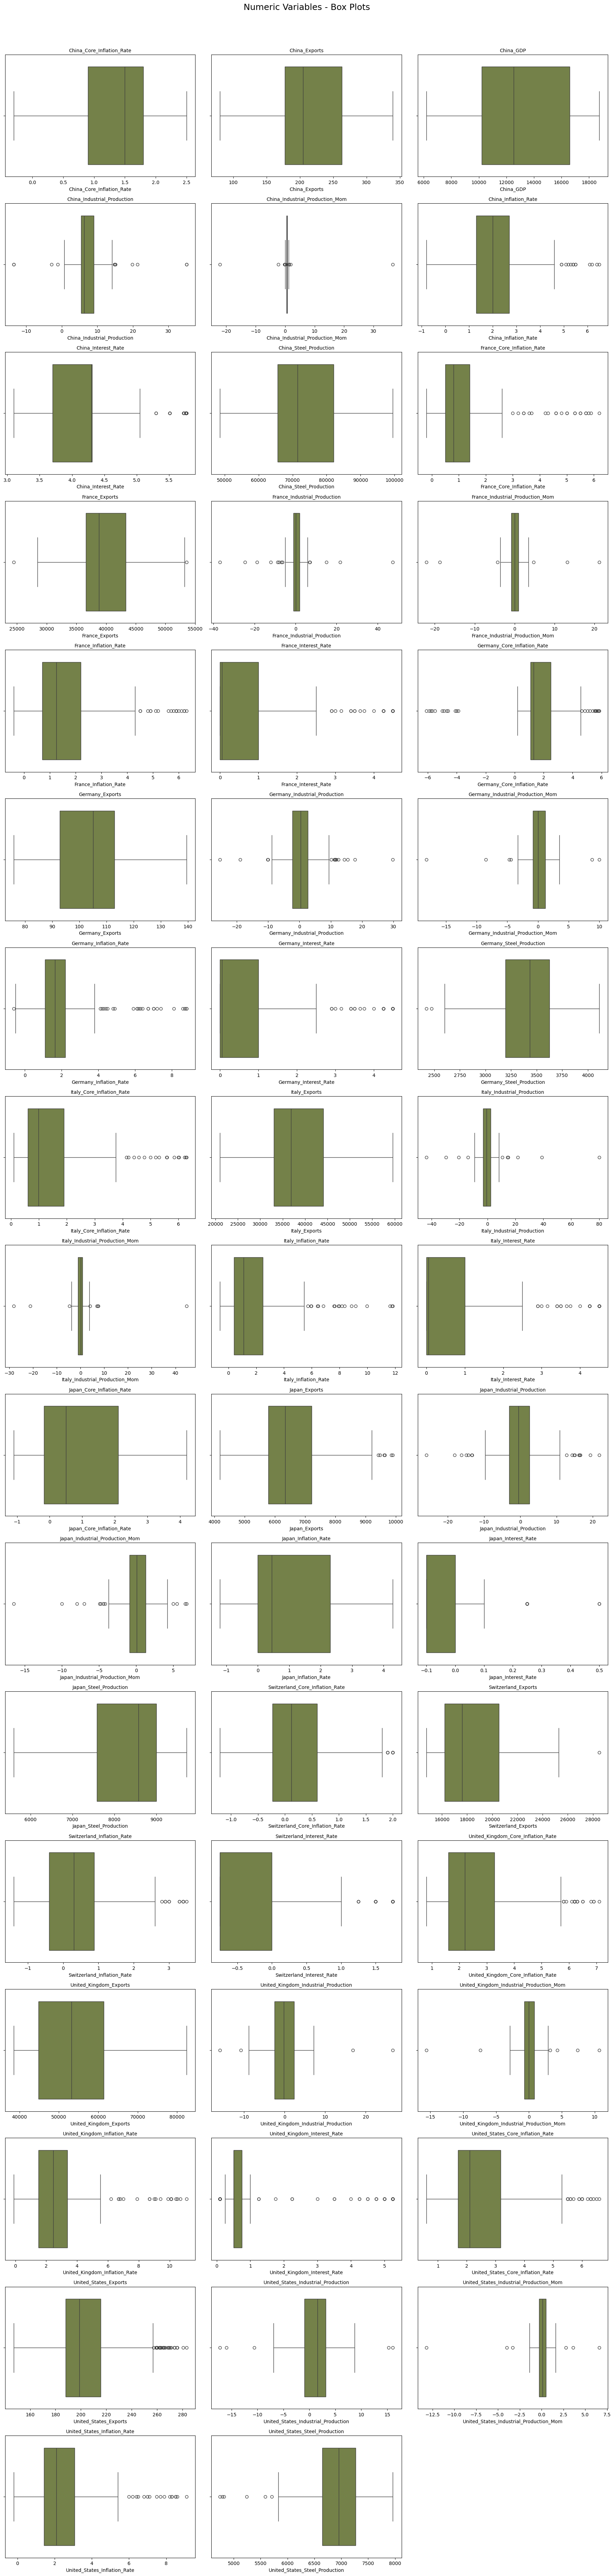

In [27]:
#applying the function to our numerical features
plot_multiple_boxplots(df_market, metric_features_market)

- Even tough there are some outliers, these values correspond to real macroeconomic indicators (like inflation, post-COVID period, etc.). If we applied some capping or transformation to try handle them, we would be distorting the actual economic reality that your model needs to learn from. Therefore, we have decided to keep the data as it is for now. 

### 3.6. Checking Distribution

In [28]:
df= pd.DataFrame(train_data[metric_features_train])

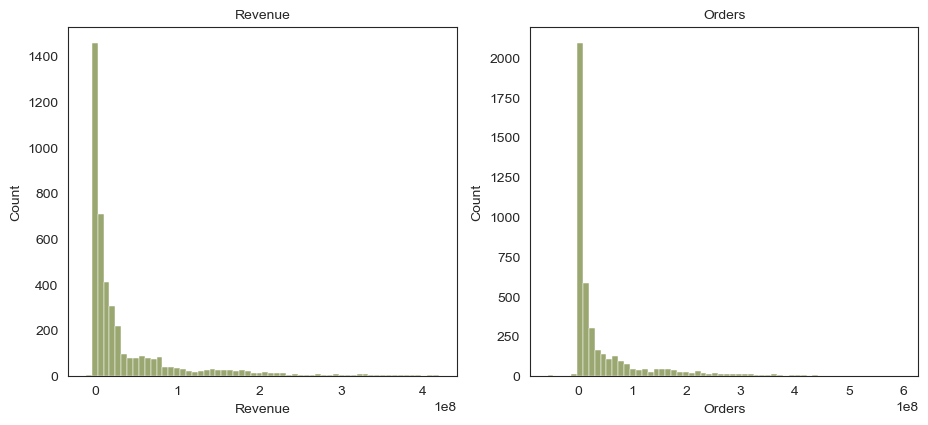

In [29]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = train_data.sample(n=min(N, len(train_data)), random_state=42)

#selecting numeric variables
cols = metric_features_train

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

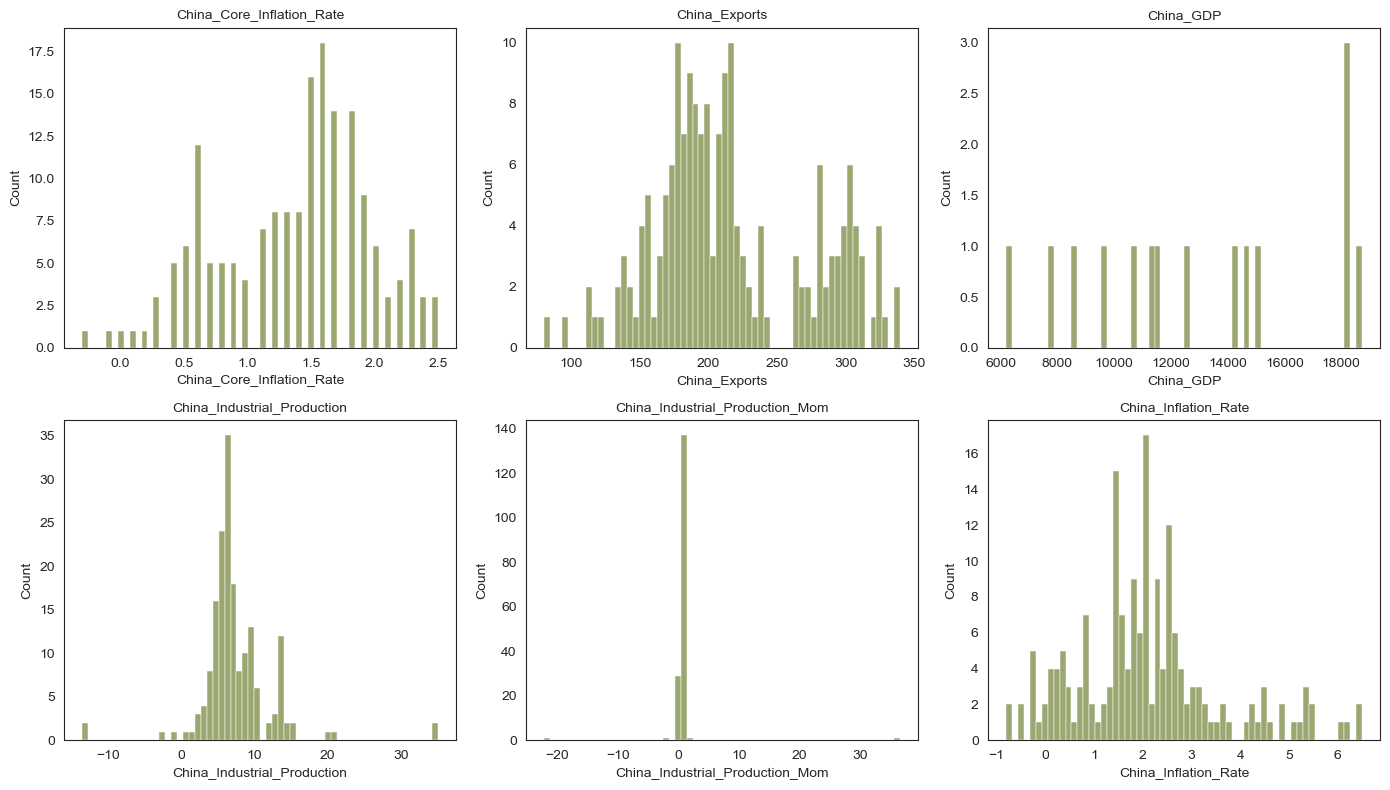

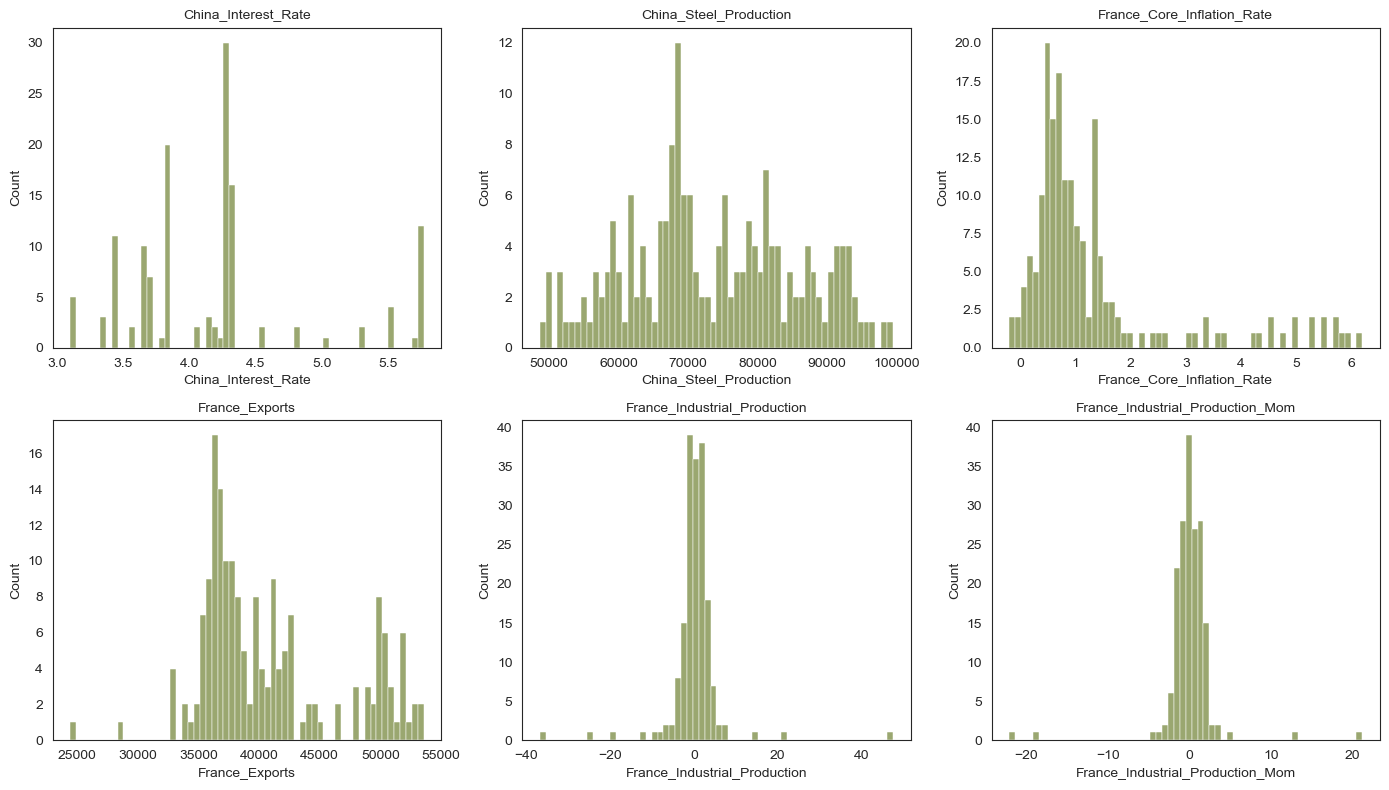

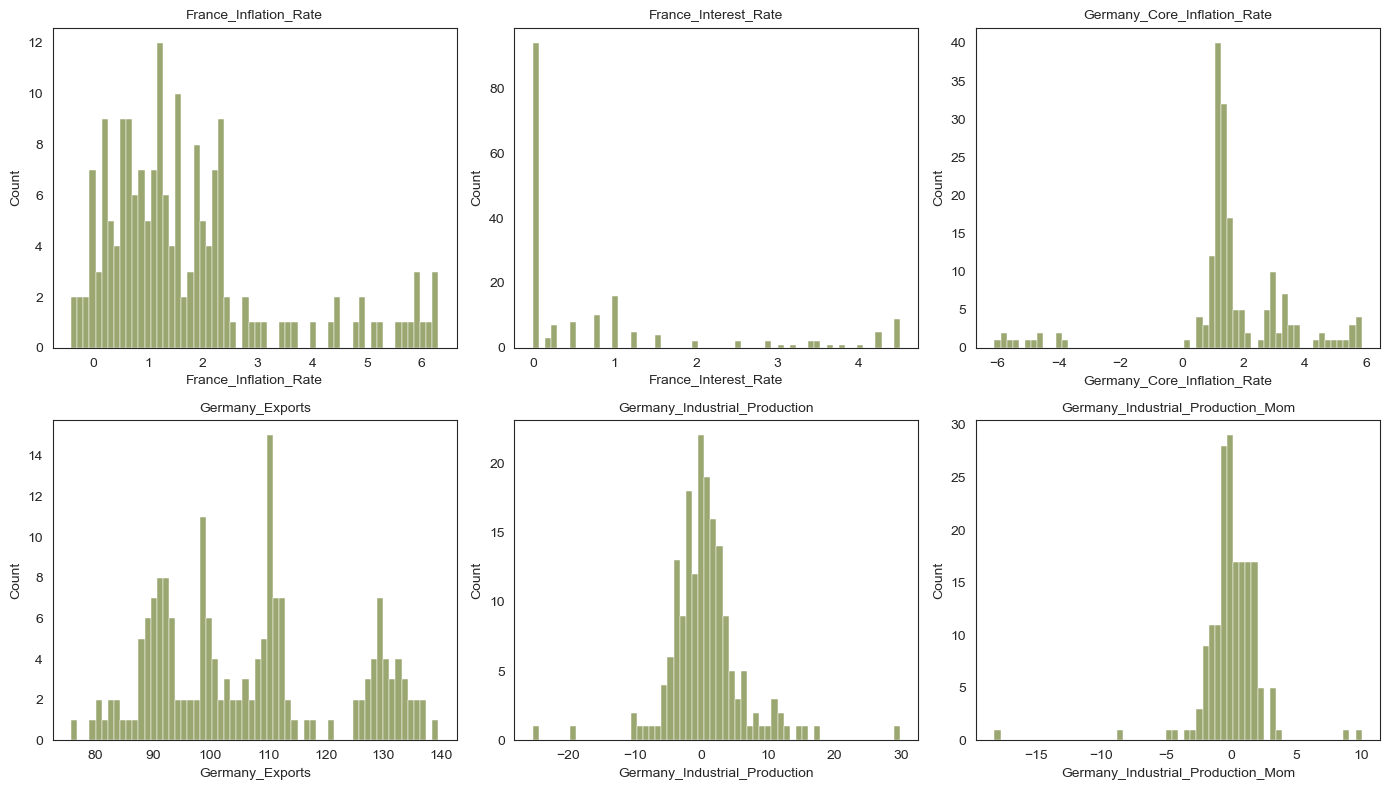

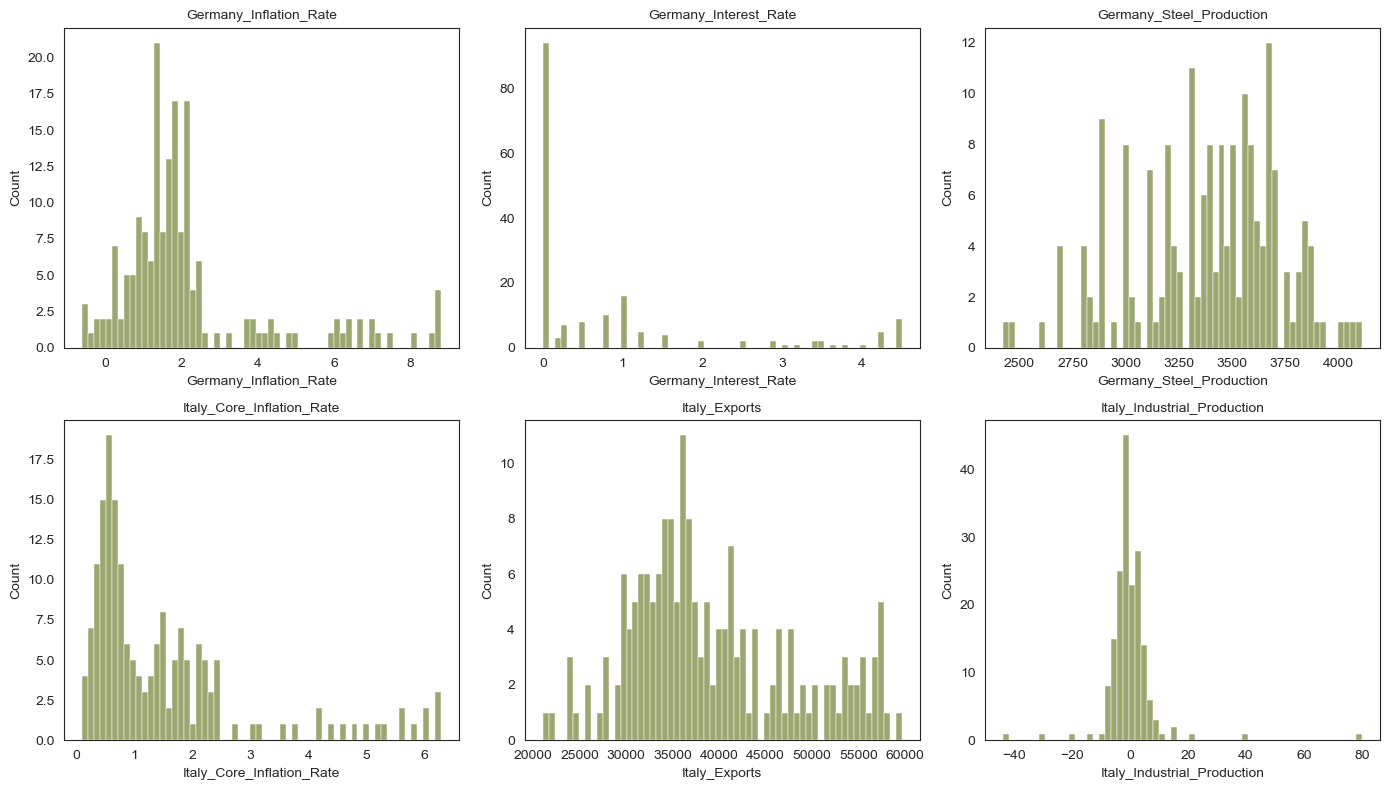

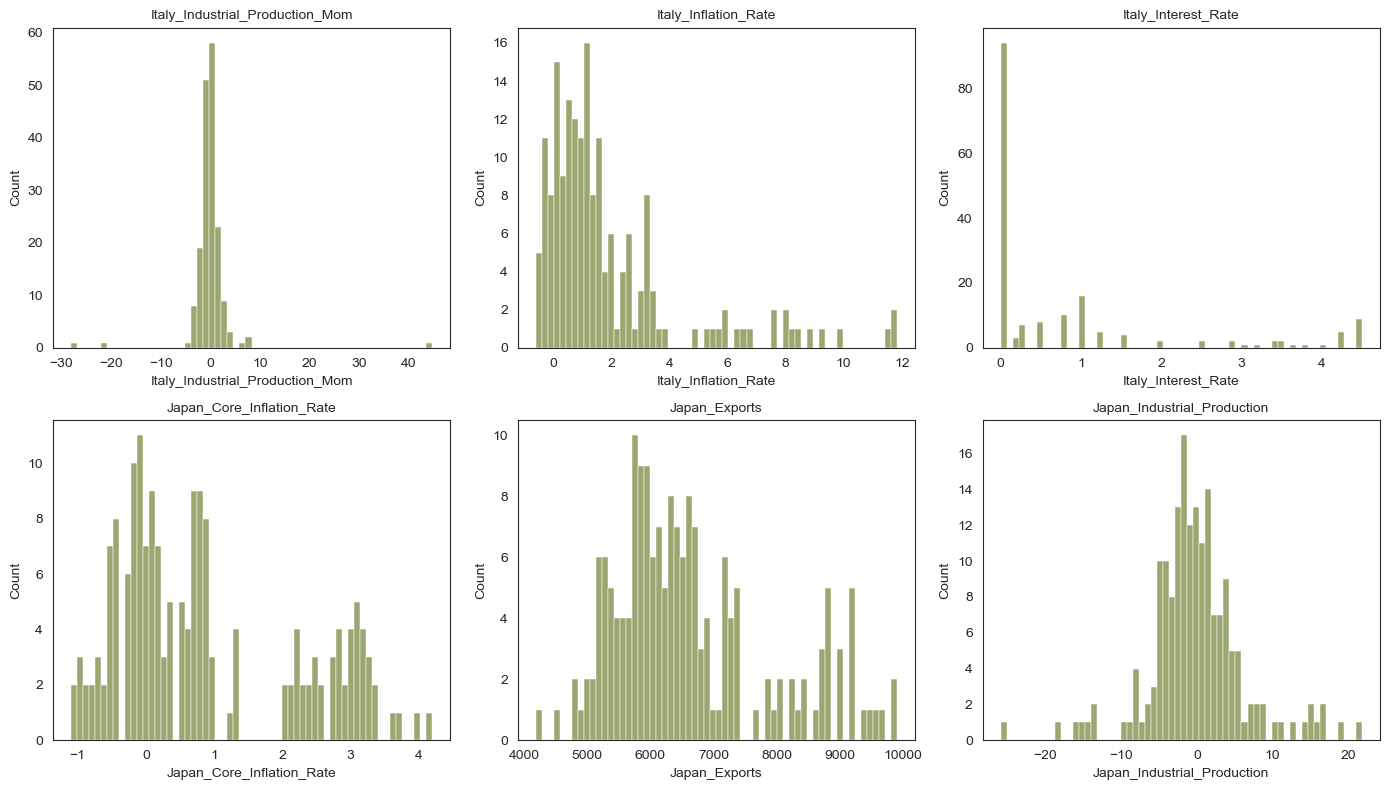

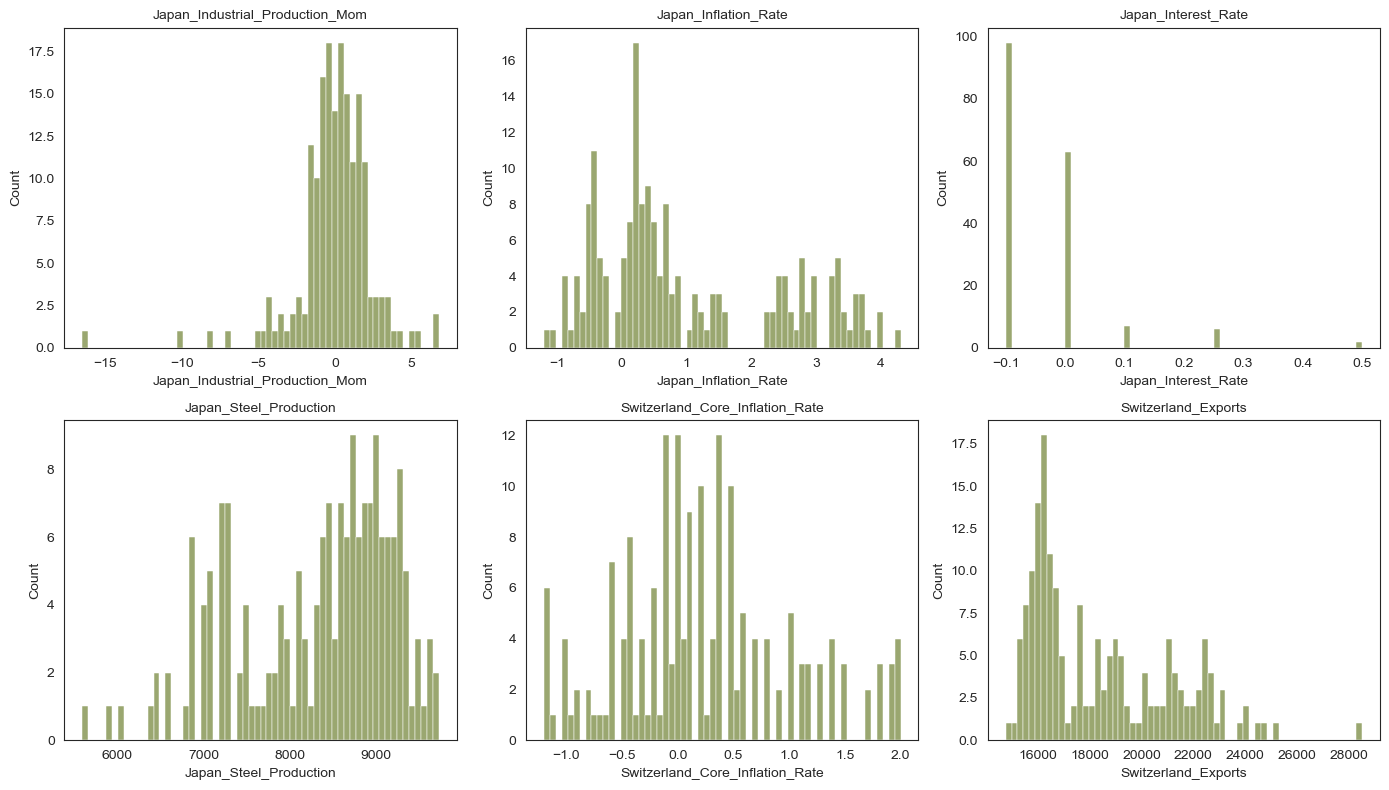

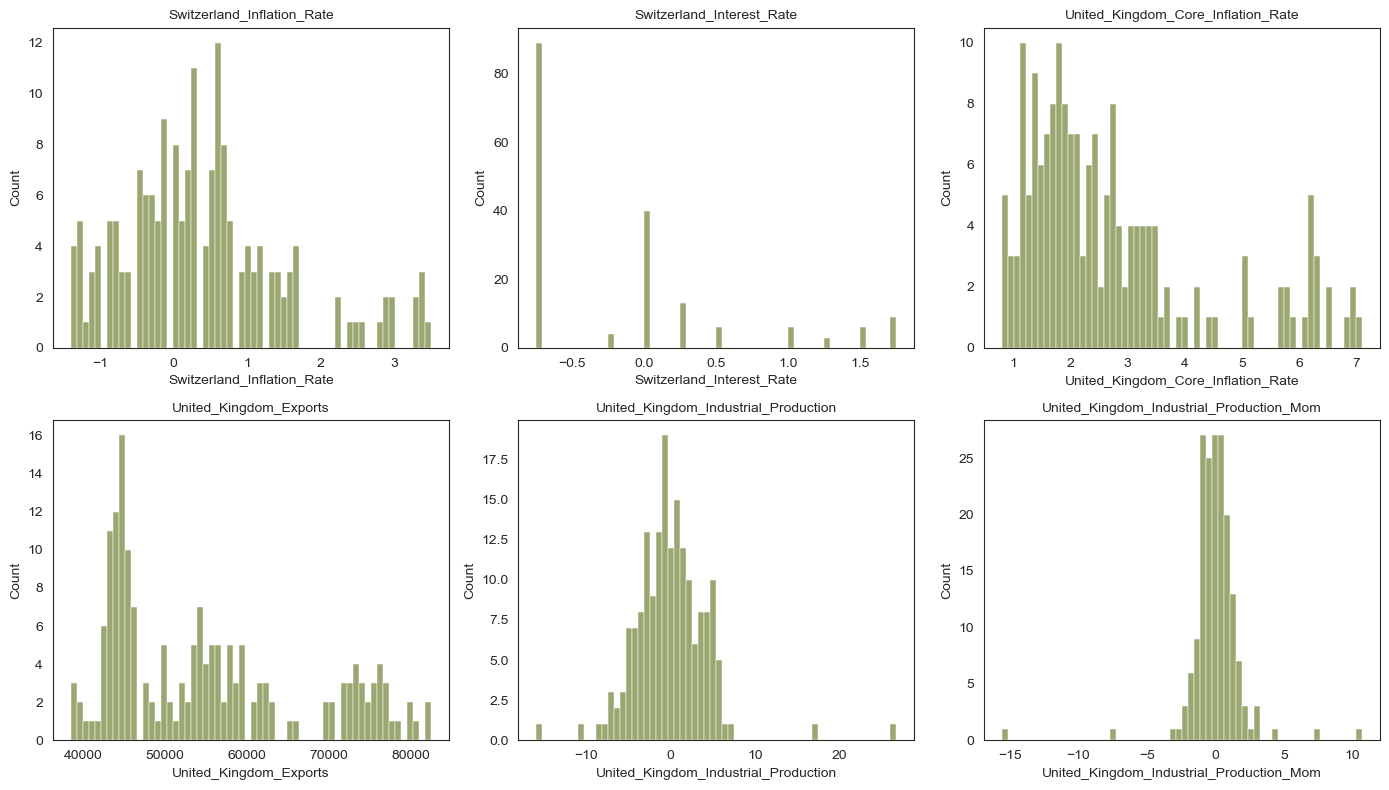

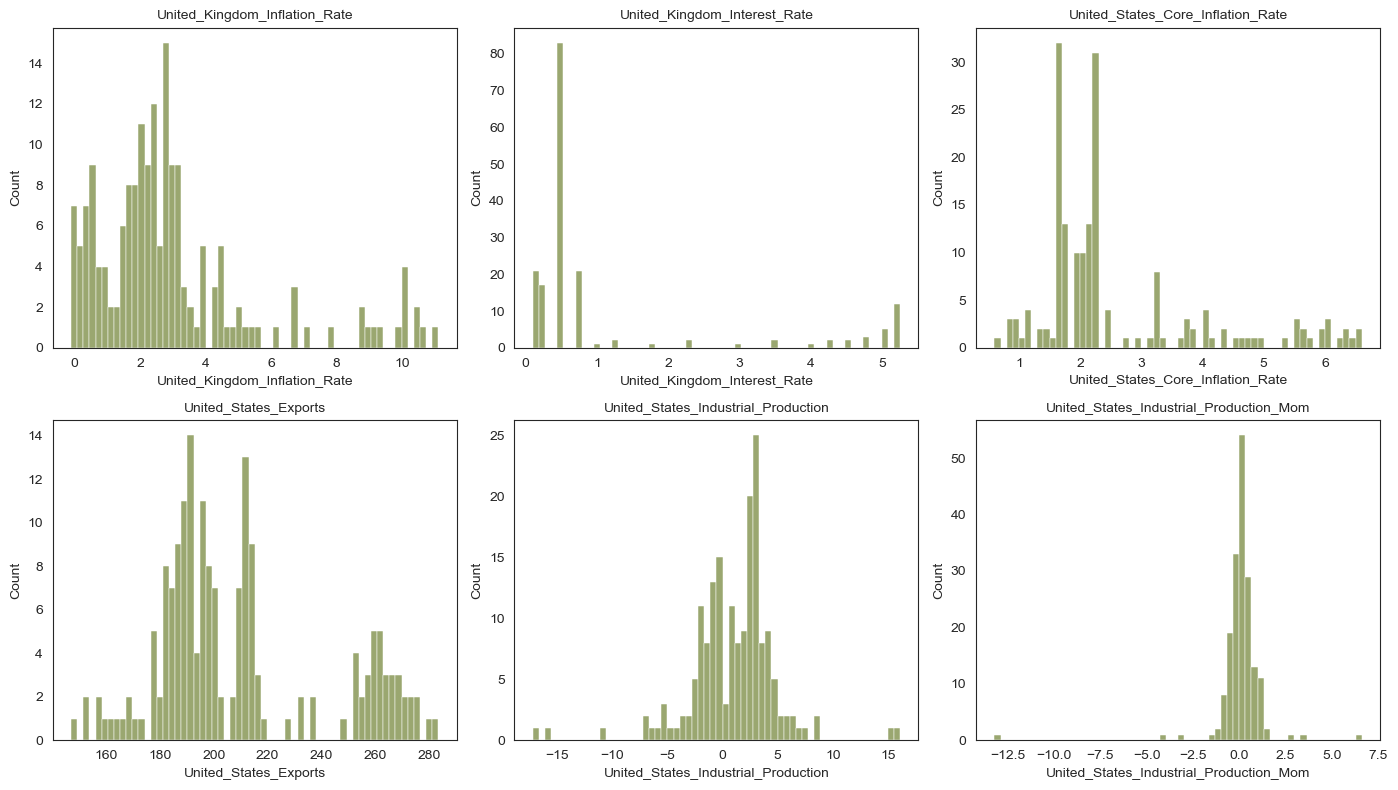

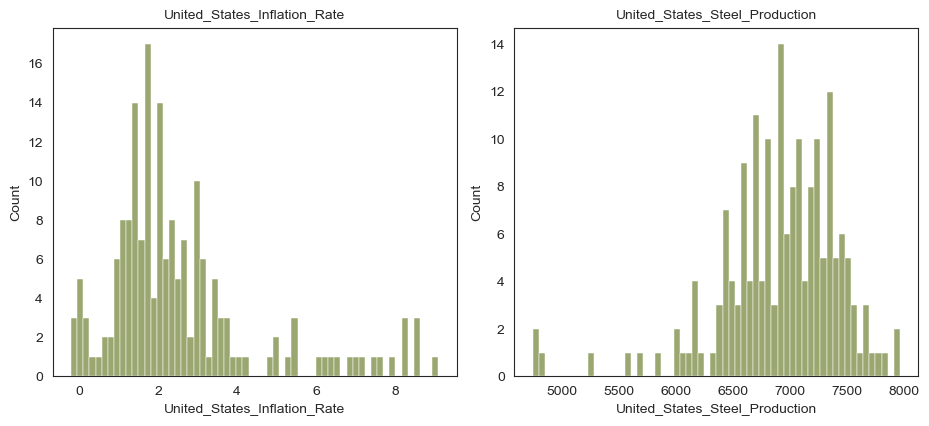

In [30]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = df_market.sample(n=min(N, len(df_market)), random_state=42)

#selecting numeric variables
cols = metric_features_market

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

### 3.7. Checking Correlation between variables

In [31]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = df_market[metric_features_market].corr(method ='spearman')
cor_spearman

,China_Core_Inflation_Rate,China_Exports,China_GDP,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,China_Steel_Production,France_Core_Inflation_Rate,France_Exports,...,United_Kingdom_Industrial_Production,United_Kingdom_Industrial_Production_Mom,United_Kingdom_Inflation_Rate,United_Kingdom_Interest_Rate,United_States_Core_Inflation_Rate,United_States_Exports,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Steel_Production
China_Core_Inflation_Rate,1.000000,-0.601535,-0.641005,0.350778,0.110067,0.489509,0.763456,-0.519185,-0.470539,-0.445736,...,0.129136,0.063294,-0.045124,-0.278393,-0.419716,-0.410172,0.244042,0.004236,-0.203296,0.346979
China_Exports,-0.601535,1.000000,0.932143,-0.534005,-0.253287,-0.556201,-0.716840,0.765034,0.413557,0.755412,...,-0.067462,-0.037299,0.165909,0.332794,0.594231,0.779905,-0.144228,-0.012998,0.491679,-0.088536
China_GDP,-0.641005,0.932143,1.000000,-0.705988,-0.536429,-0.694721,-0.943685,0.807143,0.481217,0.942857,...,-0.058981,-0.201966,0.175000,0.403616,0.703146,0.910714,-0.480787,-0.304388,0.550985,-0.175000
China_Industrial_Production,0.350778,-0.534005,-0.705988,1.000000,0.483968,0.298135,0.475174,-0.574685,-0.303811,-0.630758,...,0.088079,-0.068754,0.003491,-0.349172,-0.597015,-0.527057,0.388441,0.171938,-0.232295,0.212601
China_Industrial_Production_Mom,0.110067,-0.253287,-0.536429,0.483968,1.000000,0.304943,0.031023,-0.199254,-0.143508,-0.453833,...,-0.057605,-0.015859,-0.015704,-0.163640,-0.408471,-0.410135,-0.062856,0.074491,-0.183883,-0.031805
China_Inflation_Rate,0.489509,-0.556201,-0.694721,0.298135,0.304943,1.000000,0.473119,-0.457820,-0.131786,-0.592795,...,-0.106269,0.034190,0.105715,-0.117586,-0.334955,-0.541774,0.289531,0.082164,-0.142046,0.358545
China_Interest_Rate,0.763456,-0.716840,-0.943685,0.475174,0.031023,0.473119,1.000000,-0.594454,-0.732886,-0.712972,...,0.504204,0.089586,-0.518614,-0.386924,-0.649751,-0.619018,0.170641,-0.071090,-0.632366,0.397936
China_Steel_Production,-0.519185,0.765034,0.807143,-0.574685,-0.199254,-0.457820,-0.594454,1.000000,0.242274,0.664963,...,0.081263,0.012418,-0.018187,0.186418,0.454955,0.655751,-0.306479,0.051236,0.344398,-0.123561
France_Core_Inflation_Rate,-0.470539,0.413557,0.481217,-0.303811,-0.143508,-0.131786,-0.732886,0.242274,1.000000,0.558090,...,-0.434278,-0.130584,0.638881,0.565150,0.710207,0.464588,0.095544,-0.001930,0.687309,-0.015814
France_Exports,-0.445736,0.755412,0.942857,-0.630758,-0.453833,-0.592795,-0.712972,0.664963,0.558090,1.000000,...,-0.053031,-0.020413,0.274422,0.566934,0.774614,0.892917,-0.164116,-0.113626,0.580744,-0.117215


In [32]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap=sns.light_palette("#798a40", as_cmap=True), #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

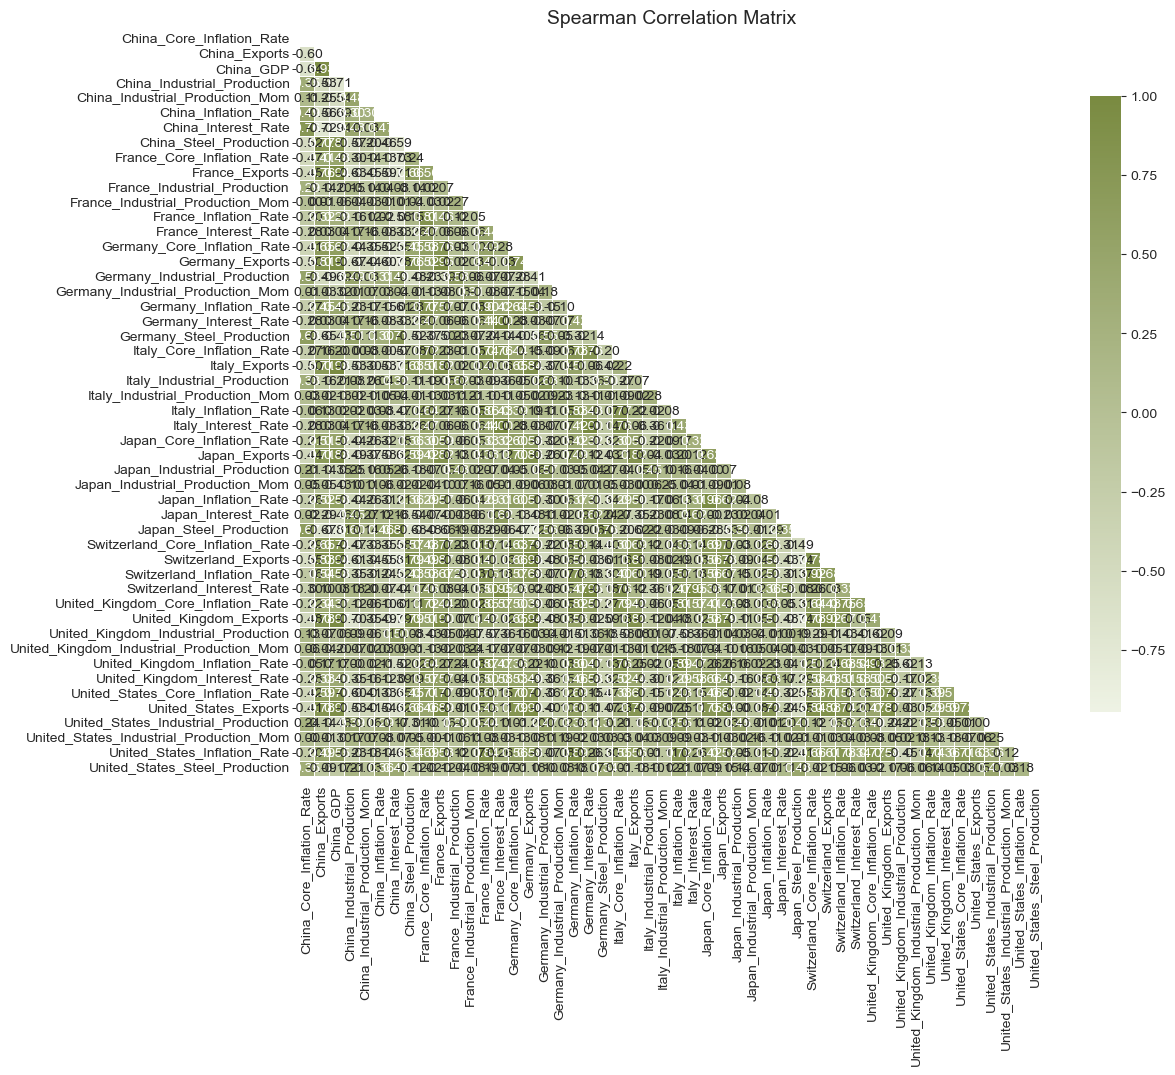

In [33]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

## 4. Data Preparation

### 4.1. Handling Missing Values

- For columns with >50% missing values (corresponding to GDP columns), we have decided to fill the missing observations with the value of the GDP of that year. 
- For columns with <50% missing values, interpolation is going to be applied in order to fill them. 
- Columns whose missing values reach 100% in positive months (corresponding to steel production of some countries), we have decided to drop those columns, since it does not contain relevant information that could be used in the model later on. 

In [34]:
# columns to drop - steel production countries with 100% missing in periods 1-48
cols_to_drop = [
    'France_Steel_Production',
    'Italy_Steel_Production',
    'United_Kingdom_Steel_Production'
]
df_market = df_market.drop(columns=cols_to_drop)

# identify GDP columns (more than 50% missing) vs other columns
missing_pct = df_market.isna().sum() / len(df_market) * 100
gdp_cols    = missing_pct[missing_pct > 50].index.tolist()
other_cols  = missing_pct[(missing_pct > 0) & (missing_pct <= 50)].index.tolist()

print("GDP columns to forward-fill:", gdp_cols)
print("Other columns to interpolate:", other_cols)

# forward-fill GDP columns, then backward-fill any remaining NaNs at the start
df_market = df_market.sort_values('Period').reset_index(drop=True)
df_market[gdp_cols] = df_market[gdp_cols].ffill().bfill()

# linear interpolation for columns with less than 50% missing + ffill/bfill for edges
df_market[other_cols] = df_market[other_cols].interpolate(method='linear').ffill().bfill()

# verify no missing values remain
remaining = df_market.isna().sum()
remaining = remaining[remaining > 0]
print("\nRemaining missing values:")
print(remaining if len(remaining) > 0 else "None - all clean!")

GDP columns to forward-fill: ['China_GDP', 'China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'France_GDP', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 'Germany_GDP', 'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 'Italy_GDP', 'Italy_GDP_from_Construction', 'Italy_GDP_from_Manufacturing', 'Japan_GDP', 'Japan_GDP_from_Construction', 'Japan_GDP_from_Manufacturing', 'Switzerland_GDP', 'Switzerland_Industrial_Production', 'Switzerland_Industrial_Production_Mom', 'United_Kingdom_GDP', 'United_Kingdom_GDP_from_Construction', 'United_Kingdom_GDP_from_Manufacturing', 'United_States_GDP', 'United_States_GDP_from_Construction', 'United_States_GDP_from_Manufacturing']
Other columns to interpolate: ['China_Core_Inflation_Rate', 'China_Exports', 'China_Industrial_Production', 'China_Industrial_Production_Mom', 'China_Inflation_Rate', 'China_Interest_Rate', 'France_Core_Inflation_Rate', 'France_Exports', 'France_Industrial_Production', 'France_Ind

In [35]:
#checking number of missing values
df_market.isna().sum()

Period                                      0
China_Core_Inflation_Rate                   0
China_Exports                               0
China_GDP                                   0
China_GDP_from_Construction                 0
China_GDP_from_Manufacturing                0
China_Industrial_Production                 0
China_Industrial_Production_Mom             0
China_Inflation_Rate                        0
China_Interest_Rate                         0
China_Steel_Production                      0
France_Core_Inflation_Rate                  0
France_Exports                              0
France_GDP                                  0
France_GDP_from_Construction                0
France_GDP_from_Manufacturing               0
France_Industrial_Production                0
France_Industrial_Production_Mom            0
France_Inflation_Rate                       0
France_Interest_Rate                        0
Germany_Core_Inflation_Rate                 0
Germany_Exports                   

### 4.2. Merging Datasets

In [36]:
#merging the datasets on the left
df_merged = train_data.merge(df_market, on='Period', how='left')

print(df_merged.shape)

(4237, 81)


In [37]:
df_merged.head(25)

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277,0.7,263.09,14996.41,...,3.0,209.117,21354.11,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0
1,2,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,263.23,14996.41,...,3.8,211.641,21354.11,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0
2,3,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,280.30,14996.41,...,4.5,214.009,21354.11,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758,1.3,281.28,14996.41,...,4.3,216.286,21354.11,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112,1.2,293.17,14996.41,...,4.0,217.728,21354.11,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468,1.2,304.70,14996.41,...,4.0,214.183,21354.11,886.3,2276.0,3.2,-1.0,5.4,0.25,7300.0
6,7,SSI,SSI027,SSI02710,SSI02710,0,334,1.3,299.12,14996.41,...,4.6,228.772,21354.11,886.3,2276.0,4.0,1.4,6.2,0.25,7500.0
7,8,SSI,SSI027,SSI02710,SSI02710,0,334,1.2,324.28,14996.41,...,4.9,231.756,21354.11,886.3,2276.0,4.5,0.9,6.8,0.25,7200.0
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173,1.2,339.66,18201.70,...,5.5,236.793,23681.17,866.9,2358.9,3.0,-0.1,7.0,0.25,7200.0
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094,1.2,323.28,18201.70,...,6.0,232.637,23681.17,866.9,2358.9,2.4,0.0,7.5,0.25,7300.0


In [38]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 81 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    4237 non-null   Int32  
 1   Biz_Desc                                  4237 non-null   object 
 2   Business_Unit                             4237 non-null   object 
 3   Segment                                   4237 non-null   object 
 4   Subsegment                                4237 non-null   object 
 5   Orders                                    4237 non-null   Int32  
 6   Revenue                                   4237 non-null   Int32  
 7   China_Core_Inflation_Rate                 4237 non-null   float64
 8   China_Exports                             4237 non-null   float64
 9   China_GDP                                 4237 non-null   float64
 10  China_GDP_from_Construction         

In [39]:
#checking missing values after merging 
pd.set_option('display.max_rows', None)
df_merged.isna().sum()/len(df_merged) * 100

Period                                      0.0
Biz_Desc                                    0.0
Business_Unit                               0.0
Segment                                     0.0
Subsegment                                  0.0
Orders                                      0.0
Revenue                                     0.0
China_Core_Inflation_Rate                   0.0
China_Exports                               0.0
China_GDP                                   0.0
China_GDP_from_Construction                 0.0
China_GDP_from_Manufacturing                0.0
China_Industrial_Production                 0.0
China_Industrial_Production_Mom             0.0
China_Inflation_Rate                        0.0
China_Interest_Rate                         0.0
China_Steel_Production                      0.0
France_Core_Inflation_Rate                  0.0
France_Exports                              0.0
France_GDP                                  0.0
France_GDP_from_Construction            

In [40]:
# add real dates from period map
df_period_map = df_period_map.dropna(subset=['Period'])
df_period_map['Period'] = df_period_map['Period'].astype(int)
df_merged = df_merged.merge(df_period_map[['Period', 'DATE']], on='Period', how='left')
df_merged = df_merged.rename(columns={'DATE': 'Date'})

print(df_merged[['Period', 'Date']].drop_duplicates().head(10))

   Period       Date
0       1 2021-04-01
1       2 2021-05-01
2       3 2021-06-01
3       4 2021-07-01
4       5 2021-08-01
5       6 2021-09-01
6       7 2021-10-01
7       8 2021-11-01
8       9 2021-12-01
9      10 2022-01-01


In [41]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 82 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Period                                    4237 non-null   Int32         
 1   Biz_Desc                                  4237 non-null   object        
 2   Business_Unit                             4237 non-null   object        
 3   Segment                                   4237 non-null   object        
 4   Subsegment                                4237 non-null   object        
 5   Orders                                    4237 non-null   Int32         
 6   Revenue                                   4237 non-null   Int32         
 7   China_Core_Inflation_Rate                 4237 non-null   float64       
 8   China_Exports                             4237 non-null   float64       
 9   China_GDP                     

## data


In [42]:
df_merged= pd.read_csv("df_merged_1.csv")

In [43]:
df_merged.head()

,Business_Unit,Segment,Subsegment,Period,Biz_Desc,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date,Start_Period,End_Period
0,SSI027,SSI02710,SSI02710,1,SSI,0,-390277,0.7,263.09,14996.41,...,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0,2021-04-01,1,36
1,SSI027,SSI02710,SSI02710,2,SSI,0,334,0.9,263.23,14996.41,...,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0,2021-05-01,1,36
2,SSI027,SSI02710,SSI02710,3,SSI,0,334,0.9,280.30,14996.41,...,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0,2021-06-01,1,36
3,SSI027,SSI02710,SSI02710,4,SSI,0,1811758,1.3,281.28,14996.41,...,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0,2021-07-01,1,36
4,SSI027,SSI02710,SSI02710,5,SSI,0,80112,1.2,293.17,14996.41,...,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0,2021-08-01,1,36


## EXPLORATORY DATA ANALYSIS

### Trends and Seasonality

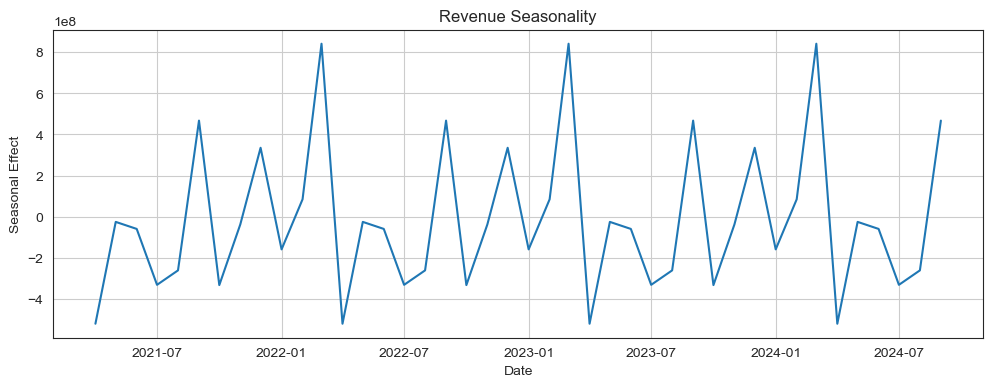

In [44]:
df_merged['Date'] = pd.to_datetime(df_merged['Date'])

# Aggregate revenue by date
ts = df_merged.groupby("Date")["Revenue"].sum().sort_index()

# Convert to monthly series
ts_monthly = ts.resample("MS").sum().interpolate()

# Extract seasonality
decomp = seasonal_decompose(ts_monthly, model="additive", period=12)

# Plot only the seasonal component
plt.figure(figsize=(12, 4))
plt.plot(decomp.seasonal)
plt.title("Revenue Seasonality")
plt.xlabel("Date")
plt.ylabel("Seasonal Effect")
plt.grid(True)
plt.show()

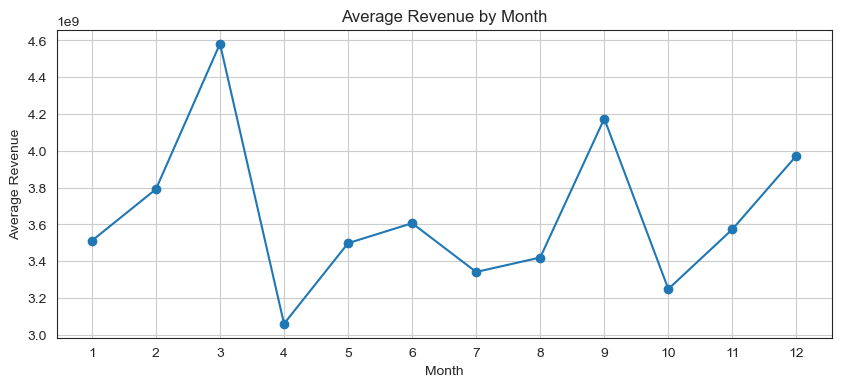

In [45]:
# Aggregate revenue by date
ts = df_merged.groupby("Date")["Revenue"].sum().sort_index()

# Convert to monthly series
ts_monthly = ts.resample("MS").sum()

# Average revenue by month
monthly_seasonality = ts_monthly.groupby(ts_monthly.index.month).mean()

# Plot seasonality by month
plt.figure(figsize=(10, 4))
plt.plot(monthly_seasonality.index, monthly_seasonality.values, marker="o")
plt.title("Average Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

The seazonality shows that march, september and december are higher revenue months and this seazonality does change throught the years.

## Hierarquies porpotions

In [46]:
fig = px.sunburst(
    df_merged,
    path=["Business_Unit", "Segment", "Subsegment"],
    values="Revenue",
    title="Revenue Hierarchy: Business Unit > Segment > Subsegment"
)

fig.show()

## Train Test Split

In [47]:
to_drop = ["Biz_Desc","Orders","Period"]
df_merged = df_merged.drop(columns=to_drop)

This code applies a rolling-origin cross-validation strategy to evaluate a time series
forecasting model. The data are ordered chronologically, and successive folds are
constructed using an expanding training window, a fixed forecasting horizon of
6 months, and a step size of 6 months.

In [48]:
# Sort data by date
df_merged = df_merged.sort_values("Date").reset_index(drop=True)

# Create X and y
X = df_merged.drop(columns=["Revenue"])
y = df_merged["Revenue"]

# Unique dates (months)
unique_dates = sorted(df_merged["Date"].unique())

# Settings
initial_train_size = 24
horizon = 6
step = 6

splits = []

for i in range(initial_train_size, len(unique_dates) - horizon + 1, step):
    train_dates = unique_dates[:i]
    test_dates = unique_dates[i:i + horizon]

    X_train = X[X["Date"].isin(train_dates)].copy()
    y_train = y[X["Date"].isin(train_dates)].copy()

    X_test = X[X["Date"].isin(test_dates)].copy()
    y_test = y[X["Date"].isin(test_dates)].copy()

    splits.append((X_train, X_test, y_train, y_test))

# Example: show all folds
for fold, (X_train, X_test, y_train, y_test) in enumerate(splits, start=1):
    print(f"Fold {fold}")
    print("Train months:", X_train["Date"].min(), "to", X_train["Date"].max())
    print("Test months:", X_test["Date"].min(), "to", X_test["Date"].max())
    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)
    print("-" * 40)

Fold 1
Train months: 2021-04-01 00:00:00 to 2023-03-01 00:00:00
Test months: 2023-04-01 00:00:00 to 2023-09-01 00:00:00
X_train shape: (3216, 80)
X_test shape: (804, 80)
----------------------------------------
Fold 2
Train months: 2021-04-01 00:00:00 to 2023-09-01 00:00:00
Test months: 2023-10-01 00:00:00 to 2024-03-01 00:00:00
X_train shape: (4020, 80)
X_test shape: (804, 80)
----------------------------------------
Fold 3
Train months: 2021-04-01 00:00:00 to 2024-03-01 00:00:00
Test months: 2024-04-01 00:00:00 to 2024-09-01 00:00:00
X_train shape: (4824, 80)
X_test shape: (804, 80)
----------------------------------------


### Correlation

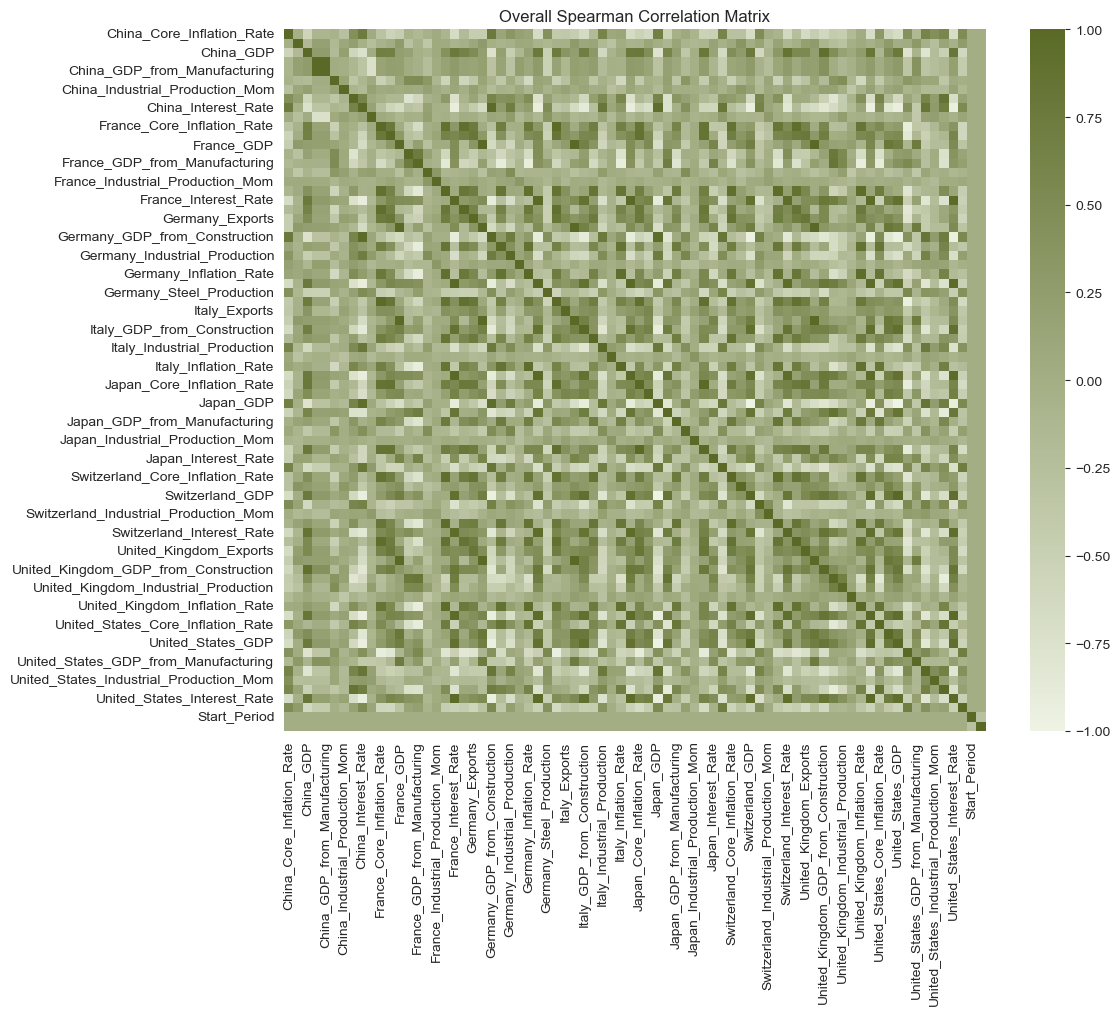

In [49]:
# Keep only numeric variables
X_num = X.select_dtypes(include="number").copy()

# Compute Spearman correlation matrix
corr_matrix = X_num.corr(method="spearman")

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap=sns.light_palette("#5a6a26", as_cmap=True), center=0, square=True)
plt.title("Overall Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

This function removes highly correlated predictors based on the absolute Spearman correlation computed. Features exceeding the specified threshold are dropped from both training and test data to reduce multicollinearity while preserving a leakage-free evaluation framework.

In [50]:
filtered_splits = []
drop_features_by_fold = []

for fold_id, (X_train, X_test, y_train, y_test) in enumerate(splits, start=1):
    X_train_filtered, X_test_filtered, to_drop = correlation_filter_train_test(
        X_train, X_test, threshold=0.8
    )

    filtered_splits.append((X_train_filtered, X_test_filtered, y_train, y_test))
    
    drop_features_by_fold.append({
        "fold": fold_id,
        "dropped_features": to_drop
    })

    print(f"Fold {fold_id}")
    print("Dropped features:", to_drop)
    print("X_train shape:", X_train_filtered.shape)
    print("X_test shape:", X_test_filtered.shape)
    print("-" * 40)

Fold 1
Dropped features: ['China_GDP_from_Manufacturing', 'China_Interest_Rate', 'France_Core_Inflation_Rate', 'France_Exports', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 'France_Inflation_Rate', 'France_Interest_Rate', 'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_GDP', 'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 'Italy_Core_Inflation_Rate', 'Italy_GDP', 'Italy_GDP_from_Construction', 'Italy_GDP_from_Manufacturing', 'Italy_Inflation_Rate', 'Italy_Interest_Rate', 'Japan_Core_Inflation_Rate', 'Japan_GDP', 'Japan_GDP_from_Manufacturing', 'Japan_Inflation_Rate', 'Japan_Steel_Production', 'Switzerland_Core_Inflation_Rate', 'Switzerland_GDP', 'Switzerland_Inflation_Rate', 'Switzerland_Interest_Rate', 'United_Kingdom_Core_Inflation_Rate', 'United_Kingdom_Exports', 'United_Kingdom_GDP', 'United_Kingdom_GDP_from_Construction', 'United_Kingdom_GDP_from_Manufacturing', 'United_Kingdom_In

### Feature Engeniring

Since CatBoost does not automatically generate time series predictors, additional
features are created to capture temporal structure and historical patterns, such as
calendar variables, lagged revenue values, and rolling statistics.

In [51]:
prepared_folds = prepare_all_folds_for_feature_selection(filtered_splits)

c:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\Siemens\Siemens git\alano testes\support.py:112: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\Siemens\Siemens git\alano testes\support.py:112: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\Siemens\Siemens git\alano testes\support.py:112: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

In [52]:
for fold in prepared_folds:
    print(f"Fold {fold['fold_id']}")
    print("X_train:", fold["X_train"].shape)
    print("y_train:", fold["y_train"].shape)
    print("X_test_base:", fold["X_test_base"].shape)
    print("-" * 40)

Fold 1
X_train: (1608, 64)
y_train: (1608,)
X_test_base: (804, 41)
----------------------------------------
Fold 2
X_train: (2412, 62)
y_train: (2412,)
X_test_base: (804, 39)
----------------------------------------
Fold 3
X_train: (3216, 65)
y_train: (3216,)
X_test_base: (804, 42)
----------------------------------------


## Feature Selection

### Mutual Information

Mutual Information is used to measure the relevance of each predictor with respect to
the target variable. Because it captures non-linear as well as linear dependencies, it
is a useful feature selection method for CatBoost, which is designed to model complex
relationships in the data.

In [53]:
mi_filtered_results = select_features_by_mi(
    prepared_folds=prepared_folds,
    mi_threshold=0.0,
    top_k=None
)

In [54]:
for result in mi_filtered_results:
    print(f"Fold {result['fold_id']}")
    print("Selected features:", len(result["selected_features"]))
    print(result["selected_features"])
    print("-" * 40)

Fold 1
Selected features: 38
['Business_Unit', 'Segment', 'Subsegment', 'series_id', 'China_Industrial_Production_Mom', 'Revenue_lag_diff_1', 'China_Industrial_Production', 'Revenue_dev_from_roll12', 'Italy_Exports', 'China_Exports', 'China_Steel_Production', 'trend_6_12', 'Germany_Industrial_Production_Mom', 'Revenue_zscore_12', 'France_GDP', 'France_Industrial_Production_Mom', 'China_GDP', 'Revenue_roll_std_12', 'Revenue_roll_mean_3', 'Japan_Industrial_Production_Mom', 'Revenue_cv_12', 'month', 'Revenue_lag_3', 'Switzerland_Exports', 'Germany_Industrial_Production', 'time_idx', 'Italy_Industrial_Production', 'Japan_GDP_from_Construction', 'Revenue_roll_mean_12', 'month_cos', 'United_Kingdom_Industrial_Production_Mom', 'Revenue_lag_diff_12', 'Revenue_lag_12', 'Revenue_rel_to_roll12', 'End_Period', 'Japan_Exports', 'Revenue_lag_1', 'Revenue_lag_6']
----------------------------------------
Fold 2
Selected features: 31
['Business_Unit', 'Segment', 'Subsegment', 'series_id', 'Revenue_cv_3

Ranking das Features

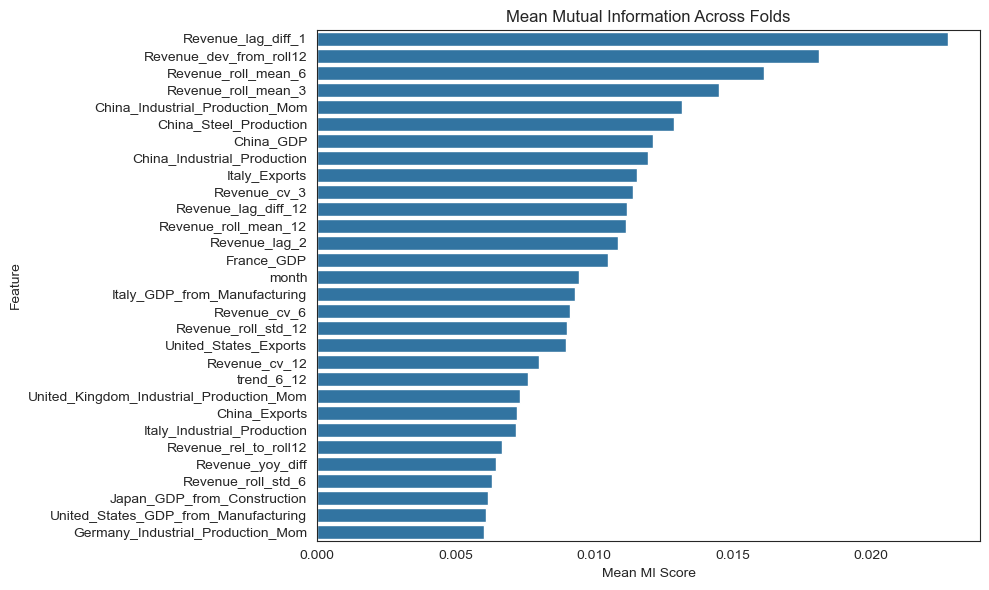

In [55]:
# Combine MI rankings from all folds
mi_all = pd.concat([result["mi_ranking"].assign(fold=result["fold_id"])for result in mi_filtered_results],
    ignore_index=True)

# Average MI by feature across folds
mi_mean = (mi_all.groupby("feature", as_index=False)["mi_score"].mean().sort_values("mi_score", ascending=False))

# Optional: keep only top 30 features
top_n = 30
mi_mean_top = mi_mean.head(top_n)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=mi_mean_top, x="mi_score", y="feature")
plt.title("Mean Mutual Information Across Folds")
plt.xlabel("Mean MI Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The heatmap shows the Mutual Information score of each predictor across folds.
Features with higher and more consistent scores are considered more informative
for the target variable, whereas predictors with near-zero or highly unstable
scores appear to have limited or fold-dependent relevance.

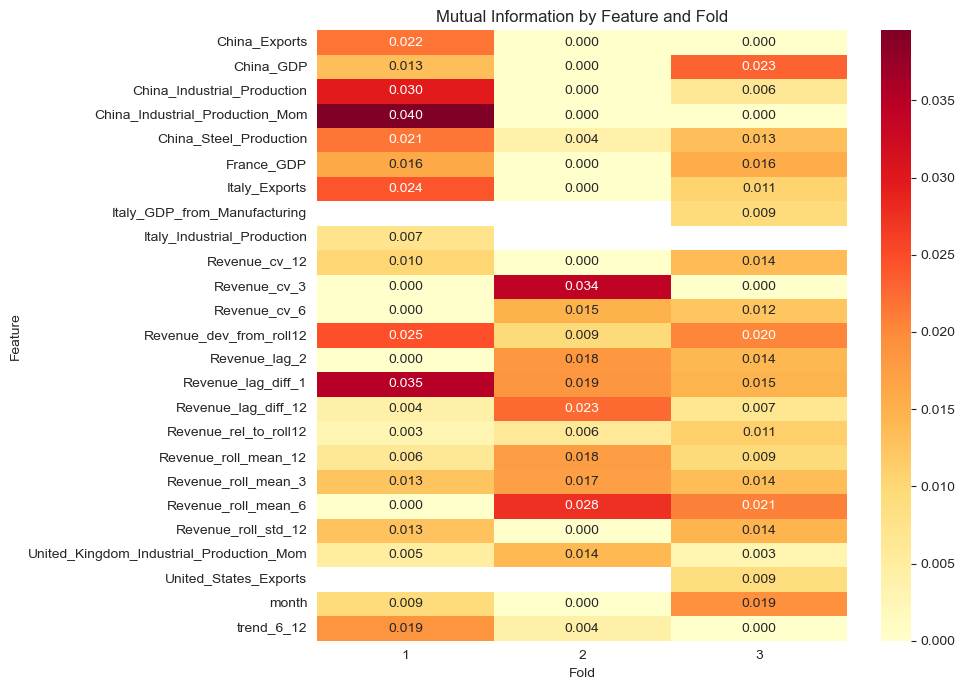

In [56]:
# Optional: keep top features by average MI
top_n = 25
top_features = (mi_all.groupby("feature")["mi_score"].mean().sort_values(ascending=False).head(top_n).index)

mi_heatmap = mi_all[mi_all["feature"].isin(top_features)].pivot(index="feature",columns="fold",values="mi_score")

# Plot
plt.figure(figsize=(10, 7))
sns.heatmap(mi_heatmap, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Mutual Information by Feature and Fold")
plt.xlabel("Fold")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### RecursiveByLossFunctionChange

The RecursiveByLossFunctionChange algorithm was adopted for feature selection because
it represents the most appropriate compromise between accuracy and computational cost
within CatBoost's recursive selection framework. While RecursiveByPredictionValuesChange
is faster but less precise, and RecursiveByShapValues is more accurate but considerably
more expensive, RecursiveByLossFunctionChange provides a robust and efficient criterion
for repeated feature selection across validation folds.

In [57]:
catboost_fs_results = []

for fold in prepared_folds:
    fold_id = fold["fold_id"]
    X_train_fold = fold["X_train"].copy()
    y_train_fold = fold["y_train"].copy()
    cat_features = fold["cat_features"]

    selected_features, eliminated_features, raw_selection = catboost_select_features_fold(
        X_train=X_train_fold,
        y_train=y_train_fold,
        cat_features=cat_features,
        total_features_to_keep=20
    )

    catboost_fs_results.append({
        "fold_id": fold_id,
        "X_train_selected": X_train_fold[selected_features].copy(),
        "y_train": y_train_fold,
        "selected_features": selected_features,
        "eliminated_features": eliminated_features,
        "cat_features": [col for col in cat_features if col in selected_features],
        "raw_selection": raw_selection
    })

In [58]:
for result in catboost_fs_results:
    print(f"Fold {result['fold_id']}")
    print("Selected features:", result["selected_features"])
    print("Eliminated features:", result["eliminated_features"])
    print("-" * 50)

Fold 1
Selected features: ['Business_Unit', 'Segment', 'Subsegment', 'series_id', 'Revenue_lag_2', 'Revenue_lag_3', 'Revenue_lag_6', 'Revenue_lag_12', 'Revenue_roll_mean_6', 'Revenue_roll_mean_12', 'Revenue_roll_std_6', 'Revenue_roll_std_12', 'Revenue_lag_diff_1', 'Revenue_cv_3', 'Revenue_cv_6', 'Revenue_cv_12', 'Revenue_dev_from_roll12', 'Revenue_zscore_12', 'trend_3_12', 'trend_6_12']
Eliminated features: ['Japan_Interest_Rate', 'China_GDP', 'year', 'Japan_GDP_from_Construction', 'France_GDP', 'quarter', 'Switzerland_Industrial_Production', 'United_States_Industrial_Production', 'China_GDP_from_Construction', 'month', 'China_Inflation_Rate', 'month_sin', 'month_cos', 'time_idx', 'China_Industrial_Production', 'Switzerland_Industrial_Production_Mom', 'United_States_Industrial_Production_Mom', 'Germany_Steel_Production', 'China_Steel_Production', 'Italy_Industrial_Production', 'United_Kingdom_Industrial_Production_Mom', 'United_Kingdom_Industrial_Production', 'China_Core_Inflation_Rate

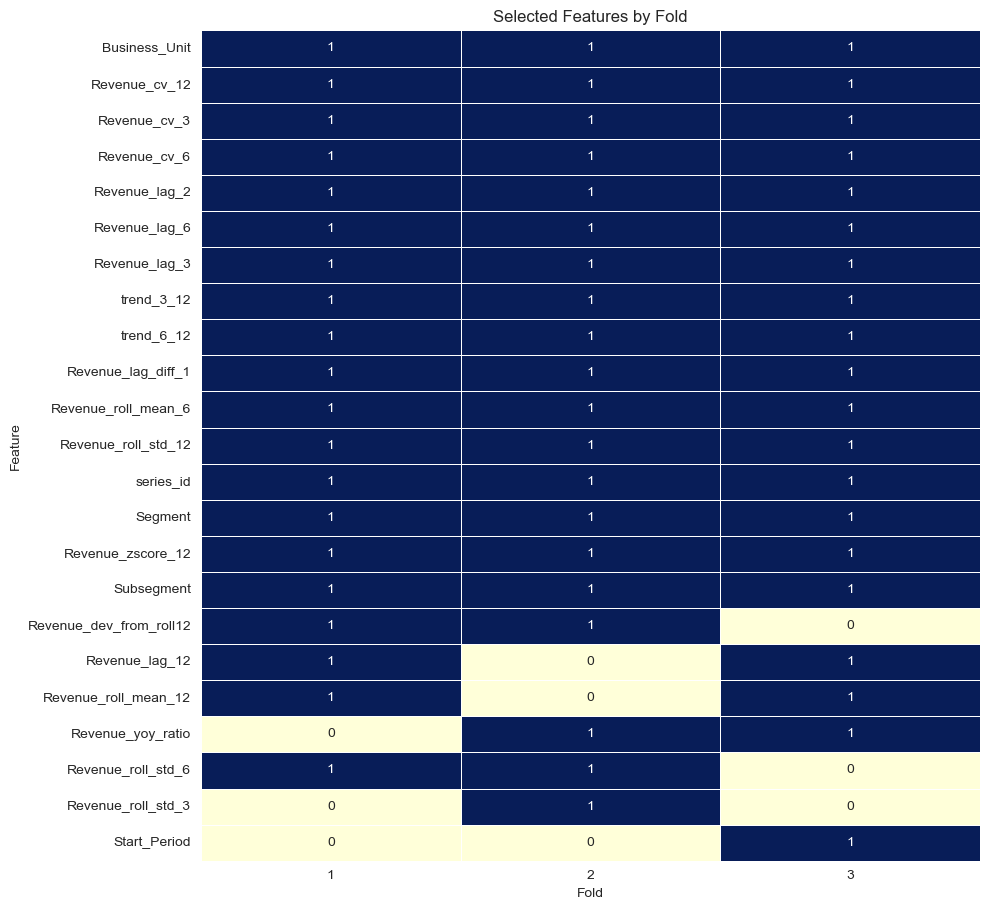

In [59]:
# Build binary selection table
selection_rows = []

for result in catboost_fs_results:
    fold_id = result["fold_id"]
    for feature in result["selected_features"]:
        selection_rows.append({
            "fold_id": fold_id,
            "feature": feature,
            "selected": 1
        })

selection_df = pd.DataFrame(selection_rows)

# Pivot to feature x fold matrix
selection_matrix = selection_df.pivot_table(
    index="feature",
    columns="fold_id",
    values="selected",
    fill_value=0
)

# Optional: sort features by selection frequency
selection_matrix["total_selected"] = selection_matrix.sum(axis=1)
selection_matrix = selection_matrix.sort_values("total_selected", ascending=False)
selection_matrix = selection_matrix.drop(columns="total_selected")

# Plot heatmap
plt.figure(figsize=(10, max(6, len(selection_matrix) * 0.4)))
sns.heatmap(
    selection_matrix,
    annot=True,
    cmap="YlGnBu",
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)
plt.title("Selected Features by Fold")
plt.xlabel("Fold")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

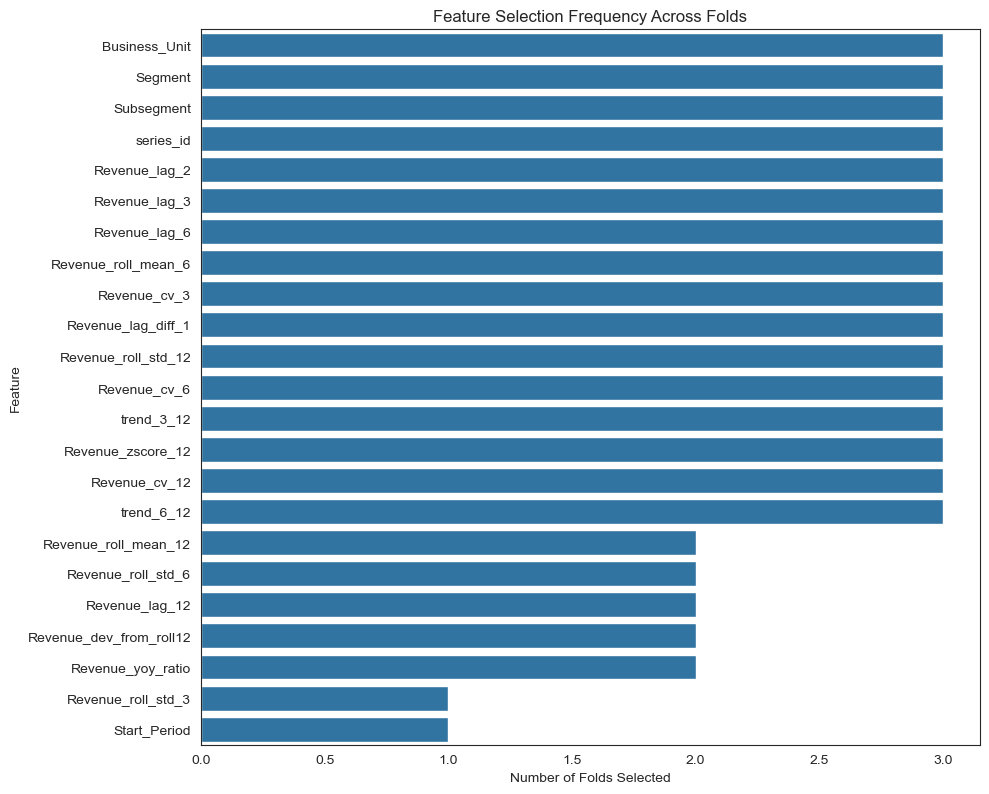

In [60]:
# Count how many times each feature was selected
feature_counts = {}

for result in catboost_fs_results:
    for feature in result["selected_features"]:
        feature_counts[feature] = feature_counts.get(feature, 0) + 1

freq_df = pd.DataFrame(
    list(feature_counts.items()),
    columns=["feature", "selection_count"]
).sort_values("selection_count", ascending=False)

# Plot
plt.figure(figsize=(10, max(6, len(freq_df) * 0.35)))
sns.barplot(
    data=freq_df,
    x="selection_count",
    y="feature"
)
plt.title("Feature Selection Frequency Across Folds")
plt.xlabel("Number of Folds Selected")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Permutation importance

Permutation importance is used to assess the contribution of each selected feature to
the predictive performance of the CatBoost model. For each fold, a baseline MAE is
computed on the trained model, after which each predictor is permuted repeatedly to
break its association with the target variable. The average increase in MAE induced
by this permutation is taken as an estimate of feature importance, with larger values
indicating greater predictive relevance.

In [61]:
permutation_results = []

for fold in prepared_folds:
    fold_id = fold["fold_id"]
    X_train = fold["X_train"].copy()
    y_train = fold["y_train"].copy()
    cat_features = fold["cat_features"]

    perm_df, trained_model, baseline_mae = manual_permutation_importance_fold(
        X_train=X_train,
        y_train=y_train,
        cat_features=cat_features,
        n_repeats=30,
        random_state=42
    )

    permutation_results.append({
        "fold_id": fold_id,
        "permutation_importance": perm_df,
        "baseline_mae": baseline_mae,
        "model": trained_model
    })

In [62]:
for result in permutation_results:
    print(f"Fold {result['fold_id']}")
    print("Baseline MAE:", result["baseline_mae"])
    print(result["permutation_importance"].head(10))
    print("-" * 40)

Fold 1
Baseline MAE: 20698128.887125157
                feature  importance_mean  importance_std
0          Revenue_cv_6     1.392837e+06    79835.309985
1          Revenue_cv_3     1.029913e+06    47932.393765
2         Revenue_cv_12     9.646659e+05    54422.499164
3   Revenue_roll_std_12     9.483197e+05    42466.333874
4         Revenue_lag_6     9.288104e+05    43559.245771
5     Revenue_zscore_12     8.655803e+05    59511.778007
6  Revenue_roll_mean_12     8.310564e+05    42841.721543
7         Revenue_lag_3     8.010287e+05    38699.206664
8    Revenue_roll_std_6     7.745119e+05    42878.962723
9               Segment     7.316621e+05    35967.892076
----------------------------------------
Fold 2
Baseline MAE: 21091185.013656355
               feature  importance_mean  importance_std
0   Revenue_roll_std_6    822316.398895    50931.524877
1  Revenue_roll_mean_6    812827.261199    45937.540244
2           trend_6_12    786846.567083    30173.505295
3        Revenue_lag_6    69

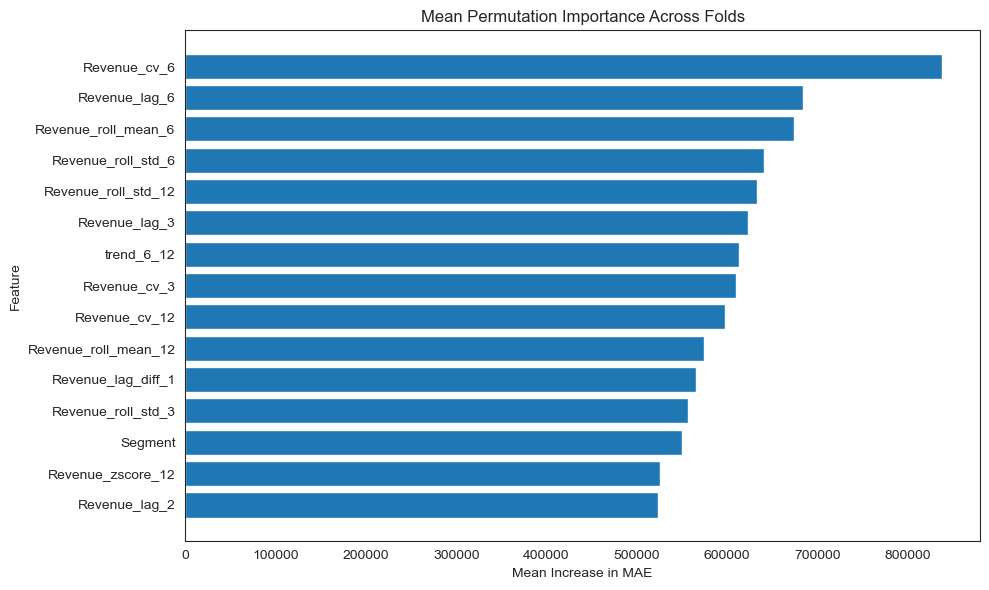

In [63]:
# Combine all folds
perm_all = pd.concat([result["permutation_importance"].assign(fold=result["fold_id"])for result in permutation_results],ignore_index=True)

# Aggregate mean importance across folds
perm_summary = (perm_all.groupby("feature", as_index=False)
    .agg(
        importance_mean=("importance_mean", "mean"),
        importance_std=("importance_mean", "std"))
    .sort_values("importance_mean", ascending=False))

# Optional: top N features
top_n = 15
perm_summary_top = perm_summary.head(top_n).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    perm_summary_top["feature"],
    perm_summary_top["importance_mean"]
)
plt.title("Mean Permutation Importance Across Folds")
plt.xlabel("Mean Increase in MAE")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

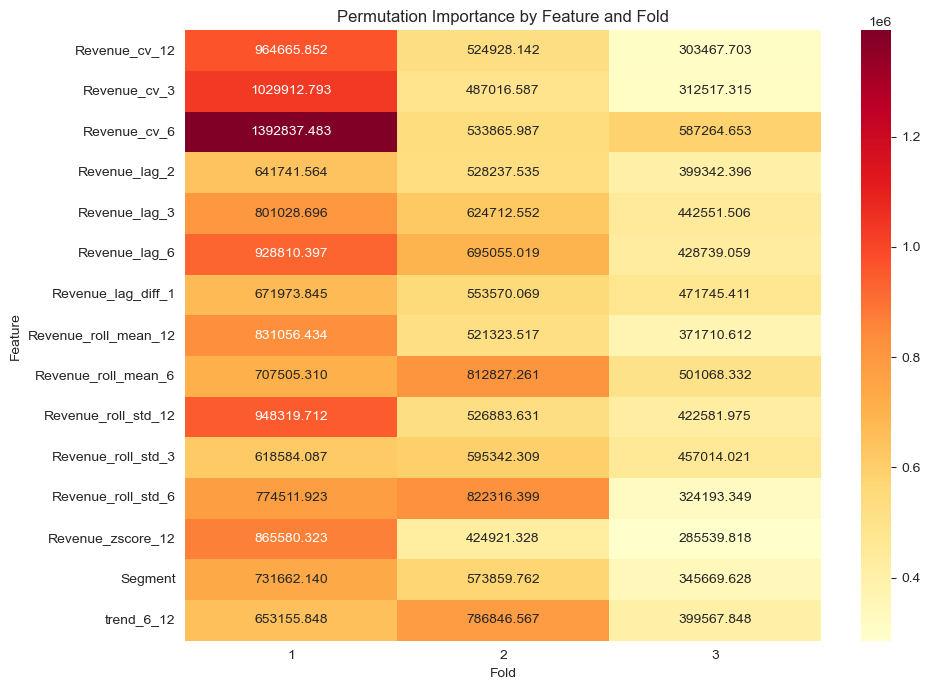

In [64]:
# Combine all folds
perm_all = pd.concat(
    [
        result["permutation_importance"].assign(fold=result["fold_id"])
        for result in permutation_results
    ],
    ignore_index=True
)

# Select top features by average importance
top_n = 15
top_features = (
    perm_all.groupby("feature")["importance_mean"]
    .mean()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

heatmap_df = perm_all[perm_all["feature"].isin(top_features)].pivot(
    index="feature",
    columns="fold",
    values="importance_mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Permutation Importance by Feature and Fold")
plt.xlabel("Fold")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Final Features

In [65]:
mi_summary_long = summarize_selected_features(
    results=mi_filtered_results,
    method_name="MI",
    feature_key="selected_features"
)

In [66]:
catboost_summary_long = summarize_selected_features(
    results=catboost_fs_results,
    method_name="CatBoost",
    feature_key="selected_features"
)

In [67]:
perm_rows = []

for result in permutation_results:
    fold_id = result["fold_id"]
    perm_df = result["permutation_importance"].copy()

    selected_features = perm_df.loc[
        perm_df["importance_mean"] > 0, "feature"
    ].tolist()

    for feature in selected_features:
        perm_rows.append({
            "fold_id": fold_id,
            "feature": feature,
            "method": "Permutation",
            "selected": 1
        })

perm_summary_long = pd.DataFrame(perm_rows)

In [68]:
all_fs_long = pd.concat(
    [mi_summary_long, catboost_summary_long, perm_summary_long],
    ignore_index=True
)

all_fs_long.head()

,fold_id,feature,method,selected
0,1,Business_Unit,MI,1
1,1,Segment,MI,1
2,1,Subsegment,MI,1
3,1,series_id,MI,1
4,1,China_Industrial_Production_Mom,MI,1


In [69]:
n_folds = len(prepared_folds)

feature_method_summary = (
    all_fs_long.groupby(["feature", "method"], as_index=False)
    .agg(folds_selected=("fold_id", "nunique"))
)

feature_method_summary["selection_rate"] = (
    feature_method_summary["folds_selected"] / n_folds
)

feature_method_summary = feature_method_summary.sort_values(
    ["method", "selection_rate", "feature"],
    ascending=[True, False, True]
)

feature_method_summary.head(10)

,feature,method,folds_selected,selection_rate
0,Business_Unit,CatBoost,3,1.0
51,Revenue_cv_12,CatBoost,3,1.0
54,Revenue_cv_3,CatBoost,3,1.0
57,Revenue_cv_6,CatBoost,3,1.0
68,Revenue_lag_2,CatBoost,3,1.0
71,Revenue_lag_3,CatBoost,3,1.0
74,Revenue_lag_6,CatBoost,3,1.0
77,Revenue_lag_diff_1,CatBoost,3,1.0
89,Revenue_roll_mean_6,CatBoost,3,1.0
92,Revenue_roll_std_12,CatBoost,3,1.0


In [70]:
feature_method_wide = feature_method_summary.pivot(
    index="feature",
    columns="method",
    values="selection_rate"
).fillna(0)

feature_method_wide = feature_method_wide.reset_index()


In [71]:
always_keep = ["Business_Unit", "Segment", "Subsegment", "series_id"]

consensus_df = feature_method_wide.copy()

# Ensure all method columns exist
for col in ["MI", "CatBoost", "Permutation"]:
    if col not in consensus_df.columns:
        consensus_df[col] = 0.0

consensus_df["methods_supporting"] = (
    (consensus_df["MI"] >= 2/3).astype(int) +
    (consensus_df["CatBoost"] >= 1/3).astype(int) +
    (consensus_df["Permutation"] >= 2/3).astype(int)
)

consensus_df["keep_recommended"] = (
    consensus_df["feature"].isin(always_keep) |
    (consensus_df["CatBoost"] >= 2/3) |
    (consensus_df["methods_supporting"] >= 3)
)

consensus_df = consensus_df.sort_values(
    ["keep_recommended", "CatBoost", "Permutation", "MI", "feature"],
    ascending=[False, False, False, False, True]
)

consensus_df

method,feature,CatBoost,MI,Permutation,methods_supporting,keep_recommended
0,Business_Unit,1.000000,1.000000,1.000000,3,True
36,Revenue_lag_diff_1,1.000000,1.000000,1.000000,3,True
48,Segment,1.000000,1.000000,1.000000,3,True
50,Subsegment,1.000000,1.000000,1.000000,3,True
64,series_id,1.000000,1.000000,1.000000,3,True
27,Revenue_cv_12,1.000000,0.666667,1.000000,3,True
29,Revenue_cv_6,1.000000,0.666667,1.000000,3,True
33,Revenue_lag_2,1.000000,0.666667,1.000000,3,True
35,Revenue_lag_6,1.000000,0.666667,1.000000,3,True
41,Revenue_roll_mean_6,1.000000,0.666667,1.000000,3,True


In [72]:
features_methods_gt2 = consensus_df.loc[
    consensus_df["methods_supporting"] > 1,
    "feature"
].tolist()

len(features_methods_gt2)

47

## MODEL

### CatBoost

This procedure implements recursive multi-step forecasting with CatBoost. The model
is trained on each fold, test features are generated from the available history only,
and predictions are iteratively fed back into the series to evaluate forecasting
performance over the 6-month horizon.

In [73]:
model_folds = []

for fold in prepared_folds:
    fold_id = fold["fold_id"]

    X_train_full = fold["X_train"].copy()
    y_train = fold["y_train"].copy()

    # Keep only selected features that exist in this fold
    selected_features = [col for col in features_methods_gt2 if col in X_train_full.columns]

    X_train_model = X_train_full[selected_features].copy()

    # Keep only categorical features that are still present
    cat_features = [col for col in fold["cat_features"] if col in selected_features]

    model_folds.append({
        "fold_id": fold_id,
        "X_train_model": X_train_model,
        "y_train": y_train,
        "selected_features": selected_features,
        "cat_features": cat_features
    })

In [74]:
metrics_df, fold_predictions = evaluate_folds(splits, model_folds)
metrics_df

,fold_id,row_mae,row_rmse,monthly_mae,monthly_rmse,true_6m_total,pred_6m_total,abs_error_6m_total,n_selected_features
0,1,5.354064e+07,7.010239e+07,4.075423e+09,5.350257e+09,21840822172,4.629336e+10,2.445254e+10,47
1,2,4.885900e+07,7.103583e+07,8.188491e+08,1.301480e+09,24885294946,2.935768e+10,4.472382e+09,47
2,3,4.000555e+07,5.820412e+07,2.012824e+09,2.219785e+09,24311515926,3.638846e+10,1.207695e+10,47


In [75]:
metrics_df.mean(numeric_only=True)

fold_id                2.000000e+00
row_mae                4.746839e+07
row_rmse               6.644745e+07
monthly_mae            2.302365e+09
monthly_rmse           2.957174e+09
true_6m_total          2.367921e+10
pred_6m_total          3.734650e+10
abs_error_6m_total     1.366729e+10
n_selected_features    4.700000e+01
dtype: float64

In [76]:
print("Average row MAE:", metrics_df["row_mae"].mean())
print("Average row RMSE:", metrics_df["row_rmse"].mean())

print("Average monthly MAE:", metrics_df["monthly_mae"].mean())
print("Average monthly RMSE:", metrics_df["monthly_rmse"].mean())

print("Average 6M absolute error:", metrics_df["abs_error_6m_total"].mean())

Average row MAE: 47468393.94085231
Average row RMSE: 66447447.771076225
Average monthly MAE: 2302365436.6626105
Average monthly RMSE: 2957174247.156261
Average 6M absolute error: 13667288445.746256


## Hyperparameters

In [77]:
param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05],
    "iterations": [300, 500, 800],
    "l2_leaf_reg": [3, 5, 7]
}

In [78]:
param_combinations = generate_param_combinations(param_grid)

In [79]:
"""results_df = test_catboost_hyperparameters_middle_out(
    splits=filtered_splits,
    selected_features=features_methods_gt2,
    param_combinations=param_combinations,
    ranking_metric="monthly_mae"
)

results_df.head(10)"""

'results_df = test_catboost_hyperparameters_middle_out(\n    splits=filtered_splits,\n    selected_features=features_methods_gt2,\n    param_combinations=param_combinations,\n    ranking_metric="monthly_mae"\n)\n\nresults_df.head(10)'

In [80]:
"""best_row = results_df.iloc[0]
best_params = best_row["params"]

print(best_params)
"""

'best_row = results_df.iloc[0]\nbest_params = best_row["params"]\n\nprint(best_params)\n'

In [81]:
best_params = {'depth': 8, 'learning_rate': 0.01, 'iterations': 300, 'l2_leaf_reg': 5}

### Catboost com hierarquia coerente

In [82]:
prepared_folds = prepare_all_folds_for_feature_selection(filtered_splits)

mi_results = select_features_by_mi(prepared_folds, mi_threshold=0.0)

catboost_results = build_catboost_results(
    prepared_folds=prepared_folds,
    total_features_to_keep=20
)

permutation_results = build_permutation_results(
    prepared_folds=prepared_folds,
    n_repeats=30,
    random_state=42
)

fold_consensus = build_consensus_features_by_fold(
    mi_results=mi_results,
    catboost_results=catboost_results,
    permutation_results=permutation_results,
    always_keep=["Business_Unit", "Segment", "Subsegment", "series_id"]
)

model_folds = build_model_folds_from_consensus(
    prepared_folds=prepared_folds,
    fold_consensus=fold_consensus
)

c:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\Siemens\Siemens git\alano testes\support.py:112: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\Siemens\Siemens git\alano testes\support.py:112: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\Siemens\Siemens git\alano testes\support.py:112: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

In [83]:
fold_metrics = []
fold_outputs = []

for fold_id, fold_split in enumerate(splits, start=1):
    selected_features_fold = next(
        item["selected_features"]
        for item in fold_consensus
        if item["fold_id"] == fold_id
    )

    model, middle_pred, top_pred, bottom_eval, monthly_bottom, metrics = run_middle_out_fold(
        fold_split=fold_split,
        selected_features=selected_features_fold,
        model_params=best_params
    )

    fold_metrics.append({
        "fold_id": fold_id,
        **metrics
    })

    fold_outputs.append({
        "fold_id": fold_id,
        "middle_pred": middle_pred,
        "top_pred": top_pred,
        "bottom_eval": bottom_eval,
        "monthly_bottom": monthly_bottom,
        "model": model
    })

metrics_df = pd.DataFrame(fold_metrics)
metrics_df

c:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\Siemens\Siemens git\alano testes\support.py:112: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\Siemens\Siemens git\alano testes\support.py:112: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\Siemens\Siemens git\alano testes\support.py:112: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

,fold_id,bottom_mae,bottom_rmse,monthly_mae,monthly_rmse,true_6m_total,pred_6m_total,abs_error_6m_total
0,1,1.279807e+07,2.753154e+07,1.220361e+08,1.513908e+08,21840822172,2.144352e+10,3.973042e+08
1,2,1.196756e+07,2.498290e+07,4.194779e+08,4.799034e+08,24885294946,2.236843e+10,2.516867e+09
2,3,1.213301e+07,2.532586e+07,2.108001e+08,2.878347e+08,24311515926,2.322460e+10,1.086913e+09


In [84]:
metrics_df["error_pct_6m_total"] = (
    metrics_df["abs_error_6m_total"] / metrics_df["true_6m_total"] * 100
).round(2)
metrics_df

,fold_id,bottom_mae,bottom_rmse,monthly_mae,monthly_rmse,true_6m_total,pred_6m_total,abs_error_6m_total,error_pct_6m_total
0,1,1.279807e+07,2.753154e+07,1.220361e+08,1.513908e+08,21840822172,2.144352e+10,3.973042e+08,1.82
1,2,1.196756e+07,2.498290e+07,4.194779e+08,4.799034e+08,24885294946,2.236843e+10,2.516867e+09,10.11
2,3,1.213301e+07,2.532586e+07,2.108001e+08,2.878347e+08,24311515926,2.322460e+10,1.086913e+09,4.47


## SHAP Analysis

In [85]:
fold_idx = 0

model = fold_predictions[fold_idx]["model"]
X_train_model = model_folds[fold_idx]["X_train_model"].copy()

In [86]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_model)

CatBoostError: Invalid type for cat_feature[non-default value idx=0,feature_idx=2]=-19505048.5 : cat_features must be integer or string, real number values and NaN values should be converted to string.

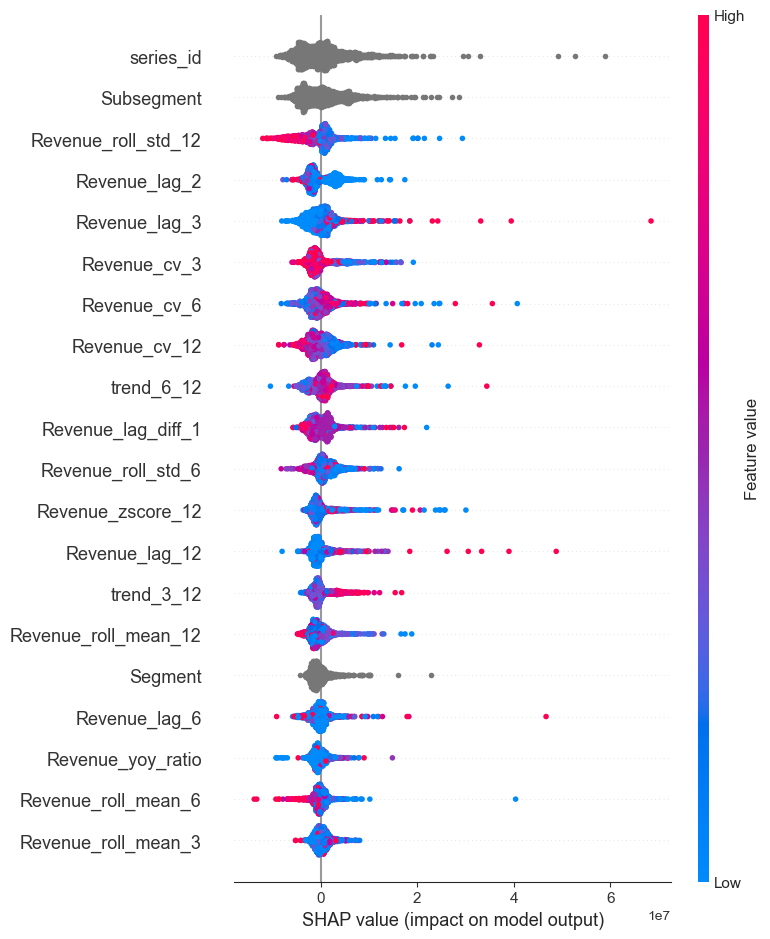

In [ ]:
shap.summary_plot(shap_values, X_train_model)

In the plots above, we can see that the features 'series_id', 'Revenue_roll_std_12' and 'Subsegment' were the most important features in predicting the revenue.

**SHAP Analysis:** SHAP explains how CatBoost makes each individual decision. 

The **bar chart** (global importance) shows the features that most influence predictions on average. 

The **beeswarm plot** is richer — each dot is a client. Dots to the right (positive SHAP) increase the revenue; to the left they decrease it. The color indicates the feature value (red=high, blue=low). E.g.: red dots on the right for revenue_lag_3 indicates that in the previous 3 months the revenue has high so it tends to predict to have a higher probability higher revenue in the month predicted — an actionable insight.

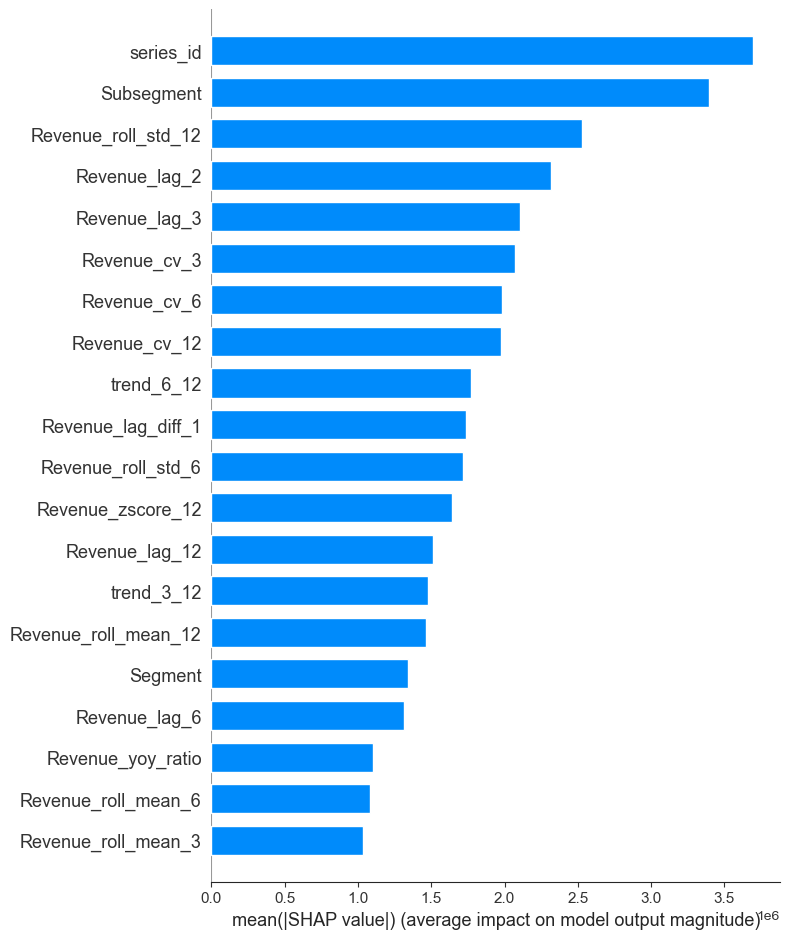

In [ ]:
shap.summary_plot(shap_values, X_train_model, plot_type="bar")

In [ ]:
shap_df = pd.DataFrame(
    shap_values,
    columns=X_train_model.columns
)

shap_df.head()

,Business_Unit,Revenue_lag_diff_1,Segment,Subsegment,series_id,Revenue_cv_12,Revenue_cv_6,Revenue_lag_2,Revenue_lag_6,Revenue_roll_mean_6,...,Germany_Industrial_Production,Germany_Industrial_Production_Mom,Italy_Exports,Japan_Exports,Revenue_yoy_diff,Switzerland_Exports,United_States_Industrial_Production_Mom,month,month_cos,month_sin
0,6.128684e+04,-2.022922e+06,-6.932703e+05,1.166307e+06,4.762862e+06,-1.125044e+06,-4.916565e+05,-3.219602e+06,2.258174e+05,-1.080526e+06,...,4.496907e+05,-18944.369904,-278063.950483,390462.729936,403681.771183,-9.695942e+05,-6492.507655,-186572.917297,102901.202544,-242544.638164
1,-5.416365e+05,2.430993e+06,-1.173618e+05,2.408221e+06,6.105751e+06,-1.985464e+06,7.167648e+05,-3.598552e+05,1.217142e+06,-5.441048e+05,...,3.949367e+05,-457238.480028,55750.904869,-347385.438722,-176338.057514,-4.666713e+05,128070.945479,-101907.946372,169250.742780,211532.378057
2,-2.501205e+05,1.566198e+06,-1.011713e+06,5.097541e+05,3.746545e+06,-3.008999e+06,1.147660e+06,2.149539e+06,9.699093e+04,-4.224411e+05,...,-1.178130e+06,331410.385045,-234347.214985,607985.901208,-172630.568762,-4.969392e+05,-223416.843741,140055.570452,-683047.467120,-39423.015527
3,-1.744543e+06,7.995040e+05,-8.311599e+05,1.836204e+06,5.546893e+06,-1.825100e+05,9.692009e+05,2.703392e+06,3.220510e+05,-3.720245e+05,...,6.819387e+05,144382.967594,803356.742447,620890.887579,110465.164072,1.348101e+06,400034.945228,113411.243710,674294.368962,540459.358509
4,-4.791873e+05,-2.519844e+06,-2.108732e+06,1.459330e+06,7.675653e+06,-6.369353e+06,-1.228292e+06,-1.084783e+06,-1.508893e+06,1.633659e+06,...,2.452610e+05,550546.338501,974545.826744,150407.955588,-124384.894213,1.596229e+06,213056.027217,223123.851276,56519.914396,505029.254875


In [ ]:
shap_importance = pd.DataFrame({
    "feature": X_train_model.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance

,feature,mean_abs_shap
4,series_id,3.693944e+06
3,Subsegment,3.391671e+06
10,Revenue_roll_std_12,2.524927e+06
7,Revenue_lag_2,2.316143e+06
13,Revenue_lag_3,2.102638e+06
12,Revenue_cv_3,2.073074e+06
6,Revenue_cv_6,1.982839e+06
5,Revenue_cv_12,1.976258e+06
11,trend_6_12,1.770005e+06
1,Revenue_lag_diff_1,1.737307e+06


## PROPHET

In [ ]:
#pip install prophet

In [ ]:
# Copy original data
df_prophet = df_merged.copy()

# Keep date as datetime
df_prophet["Date"] = pd.to_datetime(df_prophet["Date"])

# Create middle-out series id
df_prophet["unique_id"] = (
    df_prophet["Business_Unit"].astype(str) + "__" +
    df_prophet["Segment"].astype(str)
)

# Aggregate revenue by series and month
df_prophet = (
    df_prophet.groupby(["unique_id", "Business_Unit", "Segment", "Date"], as_index=False)["Revenue"]
    .sum()
    .sort_values(["unique_id", "Date"])
    .reset_index(drop=True)
)

df_prophet.head()

,unique_id,Business_Unit,Segment,Date,Revenue
0,SSI027__SSI02710,SSI027,SSI02710,2021-04-01,-390277
1,SSI027__SSI02710,SSI027,SSI02710,2021-05-01,334
2,SSI027__SSI02710,SSI027,SSI02710,2021-06-01,334
3,SSI027__SSI02710,SSI027,SSI02710,2021-07-01,1811758
4,SSI027__SSI02710,SSI027,SSI02710,2021-08-01,80112


In [ ]:
# Get unique dates
all_dates = sorted(df_prophet["Date"].unique())

# Last 6 months as test
test_dates = all_dates[-6:]
train_dates = all_dates[:-6]

df_train = df_prophet[df_prophet["Date"].isin(train_dates)].copy()
df_test = df_prophet[df_prophet["Date"].isin(test_dates)].copy()

In [ ]:
prophet_forecasts = []

for unique_id in df_train["unique_id"].unique():
    train_series = df_train[df_train["unique_id"] == unique_id].copy()

    # Prophet format
    prophet_train = train_series.rename(columns={
        "Date": "ds",
        "Revenue": "y"
    })[["ds", "y"]]

    # Fit model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    model.fit(prophet_train)

    # Forecast next 6 months
    future = model.make_future_dataframe(periods=6, freq="MS", include_history=False)
    forecast = model.predict(future)

    forecast["unique_id"] = unique_id

    prophet_forecasts.append(
        forecast[["unique_id", "ds", "yhat", "yhat_lower", "yhat_upper"]]
    )

fcst_df = pd.concat(prophet_forecasts, ignore_index=True)
fcst_df.head()

22:17:10 - cmdstanpy - INFO - Chain [1] start processing
22:17:10 - cmdstanpy - INFO - Chain [1] done processing
22:17:10 - cmdstanpy - INFO - Chain [1] start processing
22:17:10 - cmdstanpy - INFO - Chain [1] done processing
22:17:11 - cmdstanpy - INFO - Chain [1] start processing
22:17:11 - cmdstanpy - INFO - Chain [1] done processing
22:17:11 - cmdstanpy - INFO - Chain [1] start processing
22:17:11 - cmdstanpy - INFO - Chain [1] done processing
22:17:11 - cmdstanpy - INFO - Chain [1] start processing
22:17:12 - cmdstanpy - INFO - Chain [1] done processing
22:17:12 - cmdstanpy - INFO - Chain [1] start processing
22:17:12 - cmdstanpy - INFO - Chain [1] done processing
22:17:12 - cmdstanpy - INFO - Chain [1] start processing
22:17:12 - cmdstanpy - INFO - Chain [1] done processing
22:17:13 - cmdstanpy - INFO - Chain [1] start processing
22:17:13 - cmdstanpy - INFO - Chain [1] done processing
22:17:13 - cmdstanpy - INFO - Chain [1] start processing
22:17:13 - cmdstanpy - INFO - Chain [1]

,unique_id,ds,yhat,yhat_lower,yhat_upper
0,SSI027__SSI02710,2024-04-01,-3.630911e+05,-8.114203e+05,8.986305e+04
1,SSI027__SSI02710,2024-05-01,-1.153384e+05,-5.420206e+05,3.106504e+05
2,SSI027__SSI02710,2024-06-01,-1.744429e+05,-5.828473e+05,2.655193e+05
3,SSI027__SSI02710,2024-07-01,2.403577e+06,1.975780e+06,2.866212e+06
4,SSI027__SSI02710,2024-08-01,4.934956e+05,7.697418e+04,9.155073e+05


In [ ]:
# Prepare test in Prophet format
df_test_eval = df_test.rename(columns={
    "Date": "ds",
    "Revenue": "y"
})[["unique_id", "ds", "y"]].copy()

# Merge forecast with actuals
eval_df = df_test_eval.merge(
    fcst_df,
    on=["unique_id", "ds"],
    how="left"
)

# Row-level metrics
row_mae = mean_absolute_error(eval_df["y"], eval_df["yhat"])
row_rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["yhat"]))

print("Row MAE:", row_mae)
print("Row RMSE:", row_rmse)

Row MAE: 13057193.169246329
Row RMSE: 31351263.527187508


In [ ]:
monthly_eval = (
    eval_df.groupby("ds", as_index=False)[["y", "yhat"]]
    .sum()
    .sort_values("ds")
)

monthly_mae = mean_absolute_error(monthly_eval["y"], monthly_eval["yhat"])
monthly_rmse = np.sqrt(mean_squared_error(monthly_eval["y"], monthly_eval["yhat"]))

print("Monthly MAE:", monthly_mae)
print("Monthly RMSE:", monthly_rmse)

Monthly MAE: 181537062.51378497
Monthly RMSE: 213000635.87534472


In [ ]:
# Row-level percentage errors
eval_df["pct_error"] = np.where(
    eval_df["y"] != 0,
    (eval_df["yhat"] - eval_df["y"]) / eval_df["y"] * 100,
    np.nan
)

eval_df["abs_pct_error"] = np.where(
    eval_df["y"] != 0,
    np.abs(eval_df["yhat"] - eval_df["y"]) / np.abs(eval_df["y"]) * 100,
    np.nan
)

row_mape = eval_df["abs_pct_error"].mean()

# Monthly aggregated percentage errors
monthly_eval["pct_error"] = np.where(
    monthly_eval["y"] != 0,
    (monthly_eval["yhat"] - monthly_eval["y"]) / monthly_eval["y"] * 100,
    np.nan
)

monthly_eval["abs_pct_error"] = np.where(
    monthly_eval["y"] != 0,
    np.abs(monthly_eval["yhat"] - monthly_eval["y"]) / np.abs(monthly_eval["y"]) * 100,
    np.nan
)

monthly_mape = monthly_eval["abs_pct_error"].mean()

# 6-month total percentage error
true_6m_total = monthly_eval["y"].sum()
pred_6m_total = monthly_eval["yhat"].sum()
abs_error_6m_total = abs(pred_6m_total - true_6m_total)
error_pct_6m_total = abs_error_6m_total / true_6m_total * 100

print("Row MAPE (%):", row_mape.round(2))
print("Monthly MAPE (%):", monthly_mape.round(2))
print("6-month total error (%):", error_pct_6m_total.round(2))

Row MAPE (%): 33.28
Monthly MAPE (%): 4.46
6-month total error (%): 1.85
